# Arab Dialect Recognition

This notebook is a part of uni project for the Digital Signal Processing (DSP) course, it implements a classical Machine Learning model for dialect recognition specifically (used classical ML for the explainability).

The dataset used is the testing data of the open dataset "[ArabicSpeech ADI17](https://huggingface.co/datasets/ArabicSpeech/ADI17)".

## Understanding the schema

In [1]:
import pandas as pd
from pathlib import Path

PARQUET_DIR = Path("/kaggle/input/datasets/karimhassan808/arabspeech-adi17")

# ── Load just the FIRST parquet file ──────────────────────
# We only need 1 row to understand the schema
df_peek = pd.read_parquet(
    PARQUET_DIR / "0000.parquet",
    engine="pyarrow"
)

print("=" * 60)
print("SCHEMA — Column names and dtypes")
print("=" * 60)
print(df_peek.dtypes)
print(f"\nShape of file 0000.parquet: {df_peek.shape}")

print("\n" + "=" * 60)
print("FIRST ROW — All fields")
print("=" * 60)
first_row = df_peek.iloc[0]
for col in df_peek.columns:
    val = first_row[col]
    # If it's a dict (likely the audio column), show its keys
    if isinstance(val, dict):
        print(f"\n  {col} (dict):")
        for k, v in val.items():
            if hasattr(v, '__len__'):
                print(f"    {k}: type={type(v).__name__}, len={len(v)}")
            else:
                print(f"    {k}: {v}")
    elif isinstance(val, (bytes, bytearray)):
        print(f"  {col}: <bytes, length={len(val)}>")
    else:
        print(f"  {col}: {repr(val)}")

print("\n" + "=" * 60)
print("UNIQUE LABEL VALUES (from 0000.parquet)")
print("=" * 60)
# Try common column names for the dialect label
for possible_col in ['dialect', 'label', 'language', 'lang',
                     'country', 'class', 'target']:
    if possible_col in df_peek.columns:
        unique_vals = df_peek[possible_col].unique()
        print(f"\n  Column '{possible_col}' → {len(unique_vals)} unique values:")
        print(f"  {sorted(unique_vals)}")

SCHEMA — Column names and dtypes
id         object
audio      object
dialect    object
dtype: object

Shape of file 0000.parquet: (2500, 3)

FIRST ROW — All fields
  id: '1KidT1HxOyI_001677-002032'

  audio (dict):
    bytes: type=bytes, len=110636
    path: None
  dialect: 'ALG'

UNIQUE LABEL VALUES (from 0000.parquet)

  Column 'dialect' → 4 unique values:
  ['ALG', 'EGY', 'IRA', 'JOR']


##  LOAD ALL 5 PARQUET FILES, FILTER TO 4 DIALECTS

In [2]:
import pandas as pd
import numpy as np
import io
from pathlib import Path

# ── CONFIG — Edit these based on Cell 0 output ────────────
PARQUET_DIR   = Path("/kaggle/input/datasets/karimhassan808/arabspeech-adi17")
LABEL_COLUMN  = "dialect"     # ← change if Cell 0 showed a different name
AUDIO_COLUMN  = "audio"       # ← change if Cell 0 showed a different name

# The 4 dialects we want (exactly as they appear in the dataset)
TARGET_DIALECTS = ["EGY", "KSA", "LEB", "MOR"]

# How many samples per dialect to keep (balanced dataset)
# Set to None to keep ALL available samples
N_PER_DIALECT = 600           # ← adjust based on your compute budget
# ──────────────────────────────────────────────────────────

parquet_files = sorted(PARQUET_DIR.glob("*.parquet"))
print(f"Found {len(parquet_files)} parquet files:")
for f in parquet_files:
    print(f"  {f.name}")

# ── Load and concatenate all 5 files ──────────────────────
print("\nLoading parquet files...")
chunks = []
for pf in parquet_files:
    df_chunk = pd.read_parquet(pf, engine="pyarrow")
    chunks.append(df_chunk)
    print(f"  ✅ {pf.name}: {len(df_chunk):,} rows")

df_all = pd.concat(chunks, ignore_index=True)
print(f"\nTotal rows (all dialects): {len(df_all):,}")

# ── Show full label distribution BEFORE filtering ─────────
print("\n" + "=" * 50)
print("FULL LABEL DISTRIBUTION (all 17 dialects)")
print("=" * 50)
label_counts = df_all[LABEL_COLUMN].value_counts()
for label, count in label_counts.items():
    marker = " ◄ SELECTED" if label in TARGET_DIALECTS else ""
    print(f"  {label:6s}: {count:6,}{marker}")

# ── Filter to our 4 target dialects ───────────────────────
print(f"\nFiltering to: {TARGET_DIALECTS}")
df_filtered = df_all[df_all[LABEL_COLUMN].isin(TARGET_DIALECTS)].copy()
df_filtered = df_filtered.reset_index(drop=True)
print(f"Rows after dialect filter: {len(df_filtered):,}")

# ── Balance the dataset (same N per dialect) ──────────────
if N_PER_DIALECT is not None:
    balanced_parts = []
    for dialect in TARGET_DIALECTS:
        subset = df_filtered[df_filtered[LABEL_COLUMN] == dialect]
        available = len(subset)

        if available < N_PER_DIALECT:
            print(f"  ⚠️  {dialect}: only {available} available "
                  f"(wanted {N_PER_DIALECT}) — taking all")
            balanced_parts.append(subset)
        else:
            # Sample N_PER_DIALECT rows with fixed seed for reproducibility
            balanced_parts.append(
                subset.sample(n=N_PER_DIALECT, random_state=42)
            )

    df = pd.concat(balanced_parts, ignore_index=True)
    # Shuffle so dialects aren't in blocks
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
else:
    df = df_filtered.copy()

# ── Final distribution check ──────────────────────────────
print("\n" + "=" * 50)
print("FINAL DATASET — After Filtering & Balancing")
print("=" * 50)
final_counts = df[LABEL_COLUMN].value_counts()
for dialect in TARGET_DIALECTS:
    count = final_counts.get(dialect, 0)
    bar = "█" * (count // 5)
    print(f"  {dialect}: {count:4d}  {bar}")

print(f"\n  Total rows : {len(df):,}")
print(f"  Columns    : {list(df.columns)}")
print(f"  Memory     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ── Numeric label encoding ─────────────────────────────────
LABEL2IDX = {d: i for i, d in enumerate(TARGET_DIALECTS)}
IDX2LABEL = {v: k for k, v in LABEL2IDX.items()}
df["label_idx"] = df[LABEL_COLUMN].map(LABEL2IDX)

print(f"\n  Label mapping: {LABEL2IDX}")
print("\n✅ Dataset loaded and ready!")

Found 5 parquet files:
  0000.parquet
  0001.parquet
  0002.parquet
  0003.parquet
  0004.parquet

Loading parquet files...
  ✅ 0000.parquet: 2,500 rows
  ✅ 0001.parquet: 2,500 rows
  ✅ 0002.parquet: 2,500 rows
  ✅ 0003.parquet: 2,500 rows
  ✅ 0004.parquet: 2,150 rows

Total rows (all dialects): 12,150

FULL LABEL DISTRIBUTION (all 17 dialects)
  YEM   :    740
  QAT   :    740
  MOR   :    739 ◄ SELECTED
  UAE   :    737
  IRA   :    734
  LIB   :    734
  OMA   :    733
  LEB   :    731 ◄ SELECTED
  KSA   :    730 ◄ SELECTED
  SUD   :    730
  SYR   :    728
  EGY   :    727 ◄ SELECTED
  PAL   :    724
  KUW   :    723
  ALG   :    721
  JOR   :    687
  MAU   :    492

Filtering to: ['EGY', 'KSA', 'LEB', 'MOR']
Rows after dialect filter: 2,927

FINAL DATASET — After Filtering & Balancing
  EGY:  600  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  KSA:  600  ███████████████████████████████████████████████████

## VERIFICATION: Display + Play 1 sample per dialect

In [3]:
# ══════════════════════════════════════════════════════════════════
# QUICK DEBUG CELL — Run this FIRST to see exactly what's in the dict
# ══════════════════════════════════════════════════════════════════

import pandas as pd
from pathlib import Path

PARQUET_DIR  = Path("/kaggle/input/datasets/karimhassan808/arabspeech-adi17")
LABEL_COLUMN = "dialect"
AUDIO_COLUMN = "audio"

df_peek = pd.read_parquet(PARQUET_DIR / "0000.parquet", engine="pyarrow")

# Inspect the audio field of the very first row
raw = df_peek.iloc[0][AUDIO_COLUMN]

print(f"Type of audio field   : {type(raw)}")

if isinstance(raw, dict):
    print(f"Keys in audio dict    : {list(raw.keys())}")
    for k, v in raw.items():
        if isinstance(v, (bytes, bytearray)):
            print(f"  '{k}' → bytes, length = {len(v)}")
        elif hasattr(v, '__len__'):
            print(f"  '{k}' → {type(v).__name__}, length = {len(v)}, sample = {v[:3]}")
        else:
            print(f"  '{k}' → {type(v).__name__} = {repr(v)}")

elif isinstance(raw, (bytes, bytearray)):
    print(f"Audio is raw bytes    : length = {len(raw)}")

else:
    print(f"Audio value           : {repr(raw)[:200]}")

Type of audio field   : <class 'dict'>
Keys in audio dict    : ['bytes', 'path']
  'bytes' → bytes, length = 110636
  'path' → NoneType = None


In [4]:
import numpy as np
import soundfile as sf
import librosa
import io

# ── Install soundfile if needed ────────────────────────────
# !pip install soundfile -q

SR = 16000   # target sample rate

def get_audio_array(row, audio_col=AUDIO_COLUMN, target_sr=SR):
    """
    Robust audio extractor for HuggingFace parquet files.

    HuggingFace stores audio in parquet as a dict with:
      - 'bytes' : raw audio file bytes (WAV/FLAC/MP3/OPUS)
      - 'path'  : original filename (e.g. 'audio_001.wav')

    The 'array' key ONLY exists after the datasets library decodes it.
    When reading with pandas directly, we get raw bytes → decode manually.

    Handles ALL known formats:
      Format A: {'bytes': b'...', 'path': 'file.wav'}  ← HuggingFace standard
      Format B: {'array': [...], 'sampling_rate': 16000} ← pre-decoded
      Format C: raw bytes directly (not wrapped in dict)
      Format D: numpy array directly
    """
    raw = row[audio_col]

    # ── Format A: HuggingFace standard parquet format ──────
    # Dict with 'bytes' (raw file bytes) + 'path' (filename)
    if isinstance(raw, dict):
        keys = set(raw.keys())

        # Sub-format A1: has 'bytes' key → decode the file bytes
        if 'bytes' in keys and raw['bytes'] is not None:
            audio_bytes = raw['bytes']
            try:
                audio, sr = sf.read(io.BytesIO(audio_bytes), dtype='float32')
            except Exception:
                # soundfile failed → try librosa (handles more formats)
                audio, sr = librosa.load(io.BytesIO(audio_bytes), sr=None, mono=True)

        # Sub-format A2: has 'array' key → already decoded (rare in pandas)
        elif 'array' in keys:
            audio = np.array(raw['array'], dtype=np.float32)
            sr    = int(raw.get('sampling_rate', target_sr))

        # Sub-format A3: unknown dict keys → print and raise helpful error
        else:
            raise KeyError(
                f"Audio dict has unexpected keys: {keys}\n"
                f"Expected 'bytes' or 'array'. "
                f"Values preview: { {k: type(v).__name__ for k, v in raw.items()} }"
            )

    # ── Format B: raw bytes (not wrapped in dict) ──────────
    elif isinstance(raw, (bytes, bytearray)):
        try:
            audio, sr = sf.read(io.BytesIO(raw), dtype='float32')
        except Exception:
            audio, sr = librosa.load(io.BytesIO(raw), sr=None, mono=True)

    # ── Format C: numpy array directly ────────────────────
    elif isinstance(raw, np.ndarray):
        audio = raw.astype(np.float32)
        sr    = target_sr

    else:
        raise ValueError(
            f"Cannot parse audio field.\n"
            f"Type: {type(raw)}\n"
            f"Value preview: {repr(raw)[:200]}"
        )

    # ── Post-processing (same for all formats) ─────────────

    # Stereo → mono
    if audio.ndim == 2:
        audio = audio.mean(axis=1)

    # Resample to target SR if needed
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        sr    = target_sr

    # Normalize amplitude to [-1, 1]
    peak = np.max(np.abs(audio))
    if peak > 1e-8:
        audio = audio / peak

    return audio, sr

Testing get_audio_array() on 1 sample per dialect...

  🇪🇬  EGY (Egyptian  ) → 7.3s | 16000Hz | shape=(116736,) | min=-1.000 max=0.925
  🇸🇦  KSA (Gulf/Saudi) → 4.0s | 16000Hz | shape=(63488,) | min=-0.671 max=1.000
  🇱🇧  LEB (Levantine ) → 3.3s | 16000Hz | shape=(53248,) | min=-1.000 max=1.000
  🇲🇦  MOR (Maghrebi  ) → 4.2s | 16000Hz | shape=(67584,) | min=-1.000 max=0.885


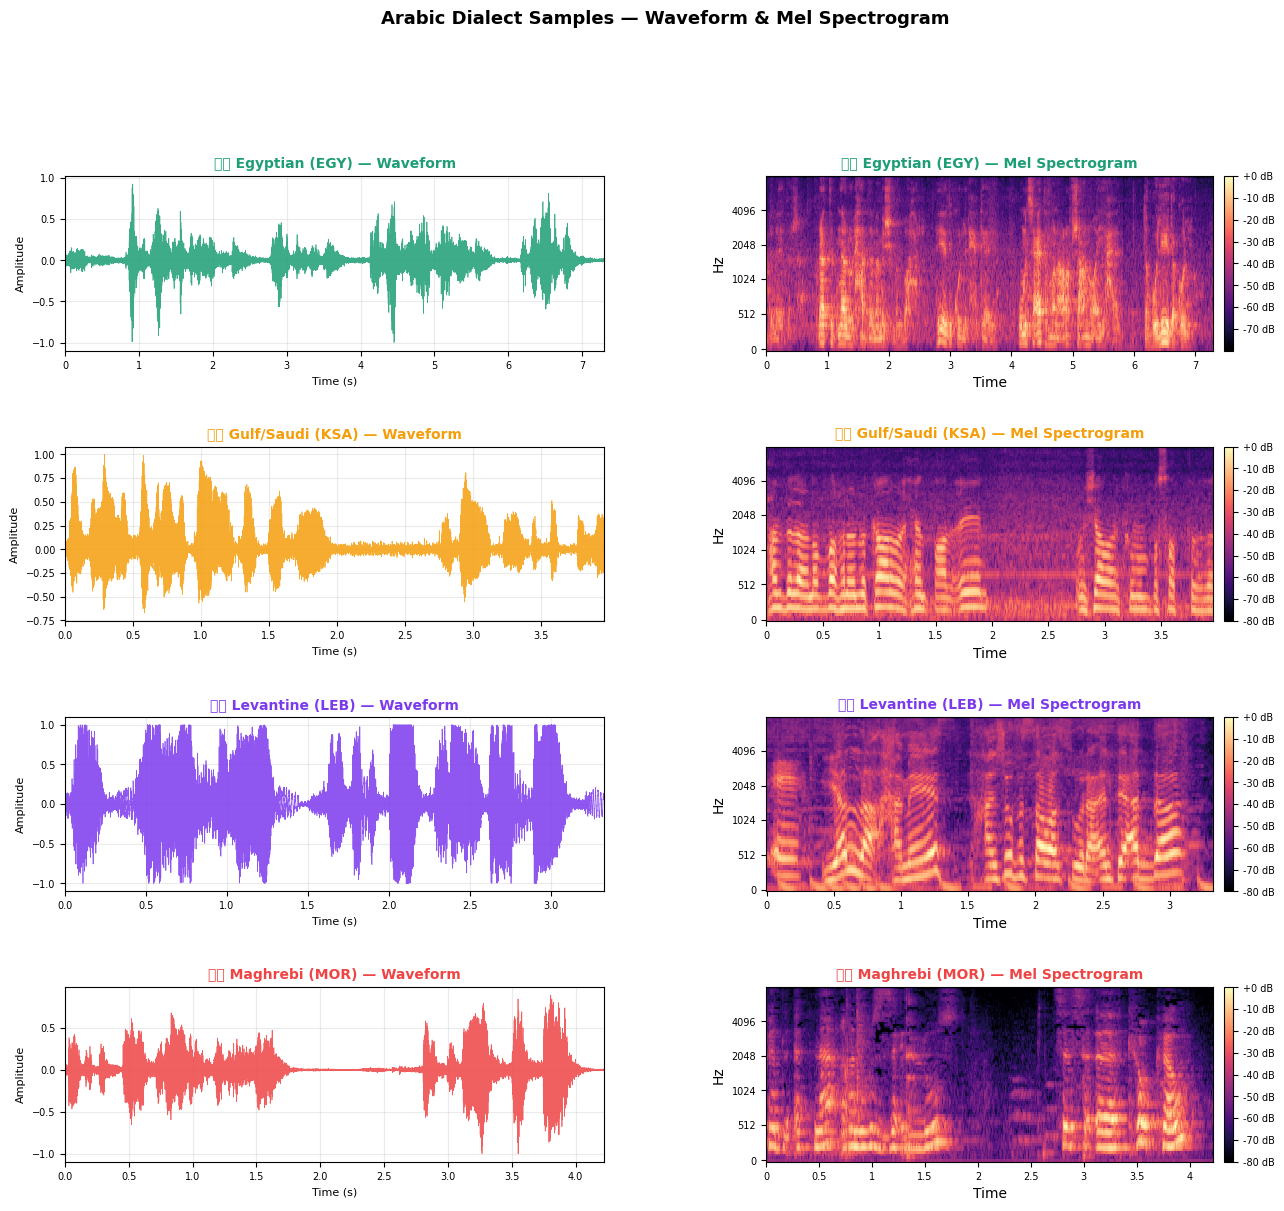


✅ Plot saved — 4/4 dialects loaded successfully

AUDIO PLAYERS


In [5]:
# ══════════════════════════════════════════════════════════════════
# VERIFICATION CELL — Test get_audio_array() on 1 sample per dialect
# ══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa.display
import warnings
from IPython.display import display, Audio, HTML
warnings.filterwarnings('ignore')

DIALECT_INFO = {
    "EGY": {"name": "Egyptian",   "color": "#1D9E75", "flag": "🇪🇬"},
    "KSA": {"name": "Gulf/Saudi", "color": "#F59E0B", "flag": "🇸🇦"},
    "LEB": {"name": "Levantine",  "color": "#7C3AED", "flag": "🇱🇧"},
    "MOR": {"name": "Maghrebi",   "color": "#EF4444", "flag": "🇲🇦"},
}

# ── Step 1: Extract 1 sample per dialect ──────────────────
print("Testing get_audio_array() on 1 sample per dialect...\n")
samples = {}

for dialect in TARGET_DIALECTS:
    subset = df[df[LABEL_COLUMN] == dialect]
    row    = subset.iloc[0]

    try:
        audio, sr = get_audio_array(row)
        duration  = len(audio) / sr
        samples[dialect] = {"audio": audio, "sr": sr, "duration": duration}
        info = DIALECT_INFO[dialect]
        print(f"  {info['flag']}  {dialect} ({info['name']:10s}) → "
              f"{duration:.1f}s | {sr}Hz | "
              f"shape={audio.shape} | "
              f"min={audio.min():.3f} max={audio.max():.3f}")

    except Exception as e:
        print(f"  ❌ {dialect} FAILED: {e}")
        # Print raw field info to help debug
        raw = row[AUDIO_COLUMN]
        print(f"     raw type = {type(raw)}")
        if isinstance(raw, dict):
            print(f"     raw keys = {list(raw.keys())}")

# ── Step 2: Plot waveforms + spectrograms ─────────────────
n_ok = len(samples)
if n_ok == 0:
    print("\n❌ No samples loaded — check error messages above")
else:
    fig = plt.figure(figsize=(16, 3.2 * n_ok))
    fig.suptitle("Arabic Dialect Samples — Waveform & Mel Spectrogram",
                 fontsize=13, fontweight="bold", y=1.01)

    gs = gridspec.GridSpec(n_ok, 2, hspace=0.55, wspace=0.3)

    for row_idx, (dialect, data) in enumerate(samples.items()):
        info  = DIALECT_INFO[dialect]
        audio = data["audio"]
        sr    = data["sr"]
        dur   = data["duration"]
        color = info["color"]

        # ── Waveform ───────────────────────────────────────
        ax_w = fig.add_subplot(gs[row_idx, 0])
        t    = np.linspace(0, dur, len(audio))
        ax_w.plot(t, audio, color=color, linewidth=0.5, alpha=0.85)
        ax_w.set_title(f"{info['flag']} {info['name']} ({dialect}) — Waveform",
                       fontsize=10, fontweight="bold", color=color)
        ax_w.set_xlabel("Time (s)", fontsize=8)
        ax_w.set_ylabel("Amplitude", fontsize=8)
        ax_w.set_xlim([0, dur])
        ax_w.tick_params(labelsize=7)
        ax_w.grid(True, alpha=0.25)

        # ── Mel Spectrogram ────────────────────────────────
        ax_s = fig.add_subplot(gs[row_idx, 1])
        mel  = librosa.feature.melspectrogram(
            y=audio, sr=sr,
            n_mels=80, n_fft=512,
            hop_length=160, win_length=400,
            fmax=8000
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        img = librosa.display.specshow(
            mel_db, sr=sr, hop_length=160,
            x_axis="time", y_axis="mel",
            fmax=8000, ax=ax_s, cmap="magma"
        )
        ax_s.set_title(f"{info['flag']} {info['name']} ({dialect}) — Mel Spectrogram",
                       fontsize=10, fontweight="bold", color=color)
        ax_s.tick_params(labelsize=7)
        fig.colorbar(img, ax=ax_s, format="%+2.0f dB",
                     pad=0.02).ax.tick_params(labelsize=7)

    plt.savefig("dialect_verification.png", dpi=150,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"\n✅ Plot saved — {n_ok}/4 dialects loaded successfully")

    # ── Step 3: Audio players ──────────────────────────────
    print("\n" + "=" * 50)
    print("AUDIO PLAYERS")
    print("=" * 50)
    for dialect, data in samples.items():
        info = DIALECT_INFO[dialect]
        display(HTML(
            f"<div style='margin:6px 0; padding:5px 12px; "
            f"border-left:4px solid {info['color']}; "
            f"background:{info['color']}18; border-radius:4px'>"
            f"<b style='color:{info['color']}'>"
            f"{info['flag']} {info['name']} ({dialect})</b>"
            f" — {data['duration']:.1f}s</div>"
        ))
        display(Audio(data["audio"], rate=data["sr"]))

## Audio Preprocessing (resampling to 25 secs + labeling) 

In [6]:
# ══════════════════════════════════════════════════════════════════
# Goal 1: Ensure every clip is AT LEAST 25 seconds
#         Short clips are extended by REPEATING (tiling) the same audio
#         This preserves the speaker's voice characteristics and dialect
#         markers — no foreign audio is mixed in
# Goal 2: Label each clip with its dialect code
# Output: preprocessed_df — a clean DataFrame ready for feature extraction
# ══════════════════════════════════════════════════════════════════

import numpy as np
import librosa
import soundfile as sf
import pandas as pd
import io
import warnings
from pathlib import Path
from tqdm.notebook import tqdm          # progress bar

warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────
SR              = 16000     # target sample rate (Hz)
TARGET_DUR_SEC  = 25.0      # minimum duration we want every clip to have
TARGET_SAMPLES  = int(TARGET_DUR_SEC * SR)   # = 400,000 samples

print(f"Target duration : {TARGET_DUR_SEC}s")
print(f"Target samples  : {TARGET_SAMPLES:,} @ {SR}Hz")
print(f"Input rows      : {len(df):,}")
print(f"Dialects        : {TARGET_DIALECTS}\n")


# ══════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════

def pad_by_tiling(audio: np.ndarray, target_len: int) -> np.ndarray:
    """
    Extend a short audio clip to target_len samples by TILING (repeating).

    WHY TILING instead of zero-padding?
    ─────────────────────────────────────────────────────────────────
    Zero-padding adds silence → artificially changes energy and prosody
    features (nPVI, RMS, F0 contour), which are the dialect fingerprints
    we rely on most.

    Tiling repeats the SAME speaker's audio → features stay consistent:
      - MFCC statistics remain from the same vocal tract
      - F0 distribution is preserved (same speaker pitch)
      - nPVI / rhythmic patterns are genuinely replicated
      - No foreign speaker or silence artifacts introduced

    This is equivalent to saying: "this speaker keeps talking in the
    same style" — a valid assumption for dialect identification since
    we only care about the dialect category, not the specific content.

    Example:
      Input:  [A B C D]      (4 samples, need 10)
      Output: [A B C D A B C D A B]   (first 10 samples of repeated tile)
    """
    if len(audio) == 0:
        return np.zeros(target_len, dtype=np.float32)

    # How many full repetitions do we need?
    repeats_needed = int(np.ceil(target_len / len(audio)))

    # Tile then slice to exact length
    tiled = np.tile(audio, repeats_needed)
    return tiled[:target_len]


def trim_to_target(audio: np.ndarray, target_len: int) -> np.ndarray:
    """
    Trim audio longer than target_len to the MIDDLE segment.

    WHY the middle? The beginning and end of a clip sometimes contain:
      - Silence / breath before speaking starts
      - Trailing silence after the last word
    The middle is the densest speech region in most recordings.
    """
    if len(audio) <= target_len:
        return audio

    start = (len(audio) - target_len) // 2
    return audio[start : start + target_len]


def normalize_amplitude(audio: np.ndarray) -> np.ndarray:
    """
    Peak-normalize to [-1, 1].
    Removes volume differences between speakers/recordings
    so that energy-based features (RMS, nPVI) reflect
    SPEECH DYNAMICS rather than microphone gain.
    """
    peak = np.max(np.abs(audio))
    if peak > 1e-8:
        return audio / peak
    return audio


def preprocess_single_clip(audio_raw: np.ndarray,
                            orig_sr: int,
                            target_sr: int  = SR,
                            target_len: int = TARGET_SAMPLES) -> np.ndarray:
    """
    Full preprocessing pipeline for a single audio clip.

    Steps:
      1. Stereo → mono (average channels)
      2. Resample to target_sr (16kHz)
      3. Peak normalize
      4. Trim silence edges (VAD-lite)
      5. Tile if shorter than target_len  ← key step
      6. Trim to exactly target_len if longer
      7. Re-normalize after tiling (tiling can introduce edge discontinuities)

    Returns: np.ndarray of shape (target_len,) dtype float32
    """
    audio = audio_raw.astype(np.float32)

    # Step 1: Stereo → mono
    if audio.ndim == 2:
        audio = audio.mean(axis=1)

    # Step 2: Resample
    if orig_sr != target_sr:
        audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=target_sr)

    # Step 3: Normalize before VAD (so top_db threshold is meaningful)
    audio = normalize_amplitude(audio)

    # Step 4: Trim leading/trailing silence
    # top_db=25: removes frames more than 25dB below peak
    # This cleans up silence at clip boundaries before tiling
    # so we don't tile silence into the repeated segments
    audio_trimmed, _ = librosa.effects.trim(audio, top_db=25)

    # Safety check: if trimming removed everything (silent clip), use original
    if len(audio_trimmed) < target_sr * 0.5:   # less than 0.5s after trim
        audio_trimmed = audio                    # fall back to un-trimmed

    # Step 5 & 6: Tile or trim to exact target length
    if len(audio_trimmed) < target_len:
        audio_final = pad_by_tiling(audio_trimmed, target_len)
    else:
        audio_final = trim_to_target(audio_trimmed, target_len)

    # Step 7: Final normalize
    audio_final = normalize_amplitude(audio_final)

    return audio_final.astype(np.float32)


# ══════════════════════════════════════════════════════════
# MAIN PREPROCESSING LOOP
# ══════════════════════════════════════════════════════════

processed_records = []   # will become our new DataFrame
errors            = []

print("Preprocessing all clips...\n")

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing"):
    dialect = row[LABEL_COLUMN]

    try:
        # ── Extract raw audio from parquet row ─────────────
        audio_raw, orig_sr = get_audio_array(row)

        # ── Run full preprocessing pipeline ────────────────
        audio_processed = preprocess_single_clip(
            audio_raw,
            orig_sr   = orig_sr,
            target_sr = SR,
            target_len= TARGET_SAMPLES
        )

        # ── Record result ───────────────────────────────────
        processed_records.append({
            "audio"      : audio_processed,   # np.ndarray (400000,)
            "dialect"    : dialect,            # e.g. "EGY"
            "label_idx"  : LABEL2IDX[dialect], # e.g. 0
            "orig_dur_s" : round(len(audio_raw) / orig_sr, 2),
            "was_tiled"  : len(librosa.effects.trim(
                               audio_raw.astype(np.float32), top_db=25
                           )[0]) < TARGET_SAMPLES,
        })

    except Exception as e:
        errors.append({"index": idx, "dialect": dialect, "error": str(e)})

# ── Build preprocessed DataFrame ──────────────────────────
preprocessed_df = pd.DataFrame(processed_records)

# ── Report ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"PREPROCESSING COMPLETE")
print(f"{'='*55}")
print(f"  Successfully processed : {len(preprocessed_df):,}")
print(f"  Errors / skipped       : {len(errors)}")
print(f"  Output shape           : {preprocessed_df.shape}")

print(f"\n  {'Dialect':<10} {'Count':>6}  {'Tiled':>6}  {'Avg orig dur':>13}")
print(f"  {'-'*40}")
for dialect in TARGET_DIALECTS:
    subset      = preprocessed_df[preprocessed_df["dialect"] == dialect]
    n_tiled     = subset["was_tiled"].sum()
    avg_orig    = subset["orig_dur_s"].mean()
    print(f"  {dialect:<10} {len(subset):>6,}  "
          f"{n_tiled:>5,} ({100*n_tiled/max(len(subset),1):.0f}%)  "
          f"{avg_orig:>10.1f}s")

print(f"\n  All audio arrays shape : ({TARGET_SAMPLES},) = {TARGET_DUR_SEC}s @ {SR}Hz")

if errors:
    print(f"\n  ⚠️  First 3 errors:")
    for e in errors[:3]:
        print(f"     Row {e['index']} [{e['dialect']}]: {e['error']}")

Target duration : 25.0s
Target samples  : 400,000 @ 16000Hz
Input rows      : 2,400
Dialects        : ['EGY', 'KSA', 'LEB', 'MOR']

Preprocessing all clips...



Preprocessing:   0%|          | 0/2400 [00:00<?, ?it/s]


PREPROCESSING COMPLETE
  Successfully processed : 2,400
  Errors / skipped       : 0
  Output shape           : (2400, 5)

  Dialect     Count   Tiled   Avg orig dur
  ----------------------------------------
  EGY           600    590 (98%)         7.8s
  KSA           600    595 (99%)         7.5s
  LEB           600    592 (99%)         7.9s
  MOR           600    589 (98%)         7.8s

  All audio arrays shape : (400000,) = 25.0s @ 16000Hz


## VERIFICATION - Visually confirm tiling works correctly

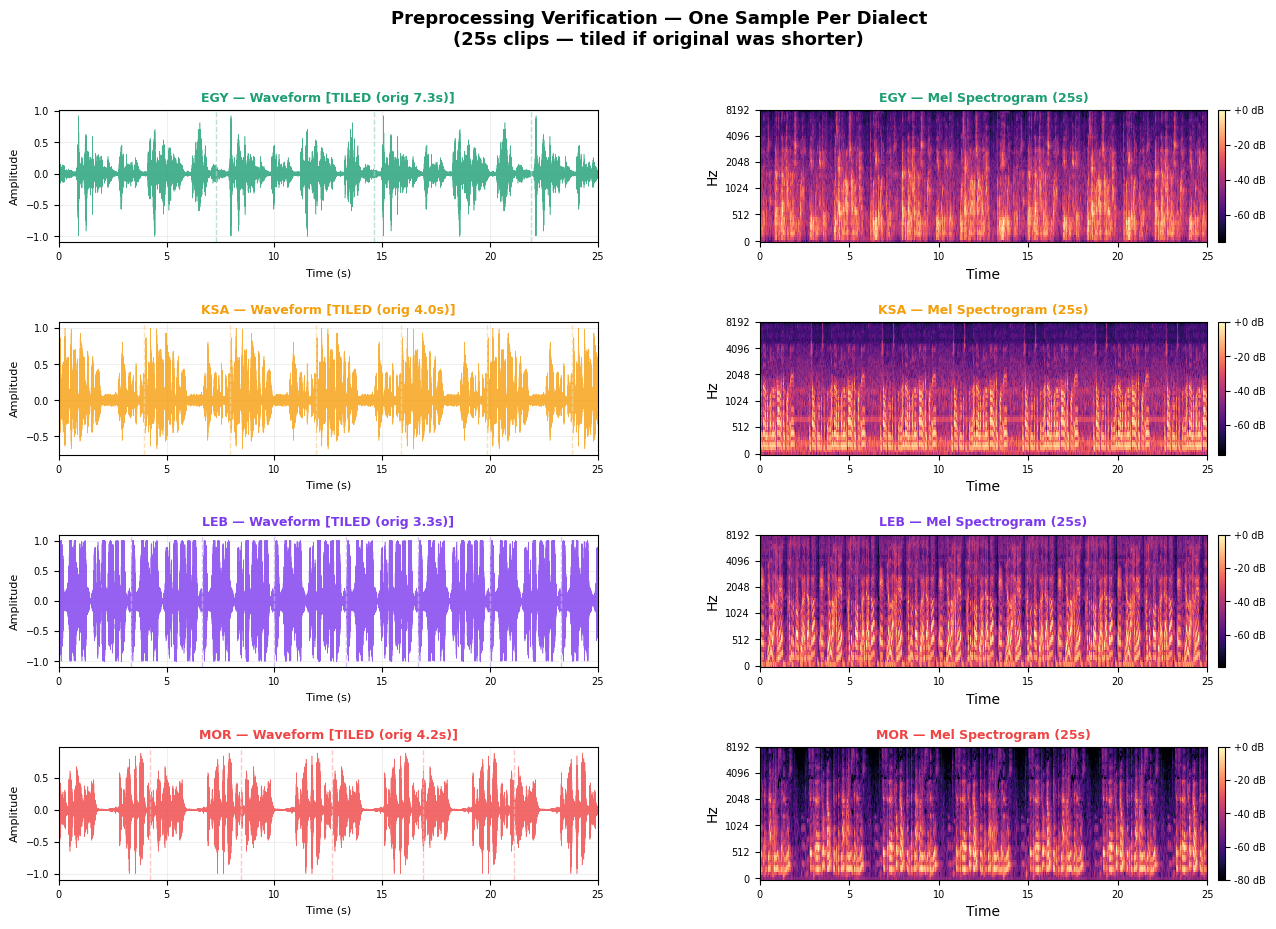


SANITY CHECKS
  ✅ EGY: length=True | finite=True | non-zero=True | n=600
  ✅ KSA: length=True | finite=True | non-zero=True | n=600
  ✅ LEB: length=True | finite=True | non-zero=True | n=600
  ✅ MOR: length=True | finite=True | non-zero=True | n=600

  🎉 All checks passed!

  preprocessed_df is ready for feature extraction.
  Shape: (2400, 5)
  Columns: ['audio', 'dialect', 'label_idx', 'orig_dur_s', 'was_tiled']


In [7]:
# ══════════════════════════════════════════════════════════════════
# Shows a TILED clip so you can see the repeated pattern clearly
# ══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DIALECT_COLORS = {
    "EGY": "#1D9E75",
    "KSA": "#F59E0B",
    "LEB": "#7C3AED",
    "MOR": "#EF4444",
}

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Preprocessing Verification — One Sample Per Dialect\n"
             "(25s clips — tiled if original was shorter)",
             fontsize=13, fontweight="bold")

gs = gridspec.GridSpec(4, 2, hspace=0.6, wspace=0.3)

for row_idx, dialect in enumerate(TARGET_DIALECTS):
    # Pick a clip that WAS tiled (more interesting to verify)
    subset_tiled = preprocessed_df[
        (preprocessed_df["dialect"] == dialect) &
        (preprocessed_df["was_tiled"] == True)
    ]
    subset_any = preprocessed_df[preprocessed_df["dialect"] == dialect]

    # Prefer a tiled sample for visualization; fall back to any sample
    sample_row = (subset_tiled.iloc[0]
                  if len(subset_tiled) > 0
                  else subset_any.iloc[0])

    audio    = sample_row["audio"]
    orig_dur = sample_row["orig_dur_s"]
    tiled    = sample_row["was_tiled"]
    color    = DIALECT_COLORS[dialect]

    assert len(audio) == TARGET_SAMPLES, \
        f"❌ {dialect}: expected {TARGET_SAMPLES} samples, got {len(audio)}"

    t = np.linspace(0, TARGET_DUR_SEC, TARGET_SAMPLES)

    # ── Waveform ───────────────────────────────────────────
    ax_w = fig.add_subplot(gs[row_idx, 0])
    ax_w.plot(t, audio, color=color, linewidth=0.4, alpha=0.8)

    # Draw vertical lines at tiling boundaries
    if tiled and orig_dur > 0:
        tile_interval = orig_dur  # approx (after silence trim it's slightly less)
        boundary = tile_interval
        while boundary < TARGET_DUR_SEC:
            ax_w.axvline(boundary, color='white', linewidth=1.0,
                         alpha=0.6, linestyle='--')
            ax_w.axvline(boundary, color=color, linewidth=1.0,
                         alpha=0.3, linestyle='--')
            boundary += tile_interval

    tiled_label = f"TILED (orig {orig_dur:.1f}s)" if tiled else f"TRIMMED (orig {orig_dur:.1f}s)"
    ax_w.set_title(f"{dialect} — Waveform [{tiled_label}]",
                   fontsize=9, fontweight="bold", color=color)
    ax_w.set_xlabel("Time (s)", fontsize=8)
    ax_w.set_ylabel("Amplitude", fontsize=8)
    ax_w.set_xlim([0, TARGET_DUR_SEC])
    ax_w.tick_params(labelsize=7)
    ax_w.grid(True, alpha=0.2)

    # ── Mel Spectrogram ────────────────────────────────────
    ax_s = fig.add_subplot(gs[row_idx, 1])
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SR,
        n_mels=64, n_fft=512,
        hop_length=160, win_length=400,
        fmax=8000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(
        mel_db, sr=SR, hop_length=160,
        x_axis="time", y_axis="mel",
        ax=ax_s, cmap="magma"
    )
    ax_s.set_title(f"{dialect} — Mel Spectrogram (25s)",
                   fontsize=9, fontweight="bold", color=color)
    ax_s.tick_params(labelsize=7)
    fig.colorbar(img, ax=ax_s, format="%+2.0f dB",
                 pad=0.02).ax.tick_params(labelsize=7)

plt.savefig("preprocessing_verification.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# ── Final sanity assertions ────────────────────────────────
print("\n" + "="*50)
print("SANITY CHECKS")
print("="*50)

all_pass = True
for dialect in TARGET_DIALECTS:
    subset = preprocessed_df[preprocessed_df["dialect"] == dialect]
    lengths = subset["audio"].apply(len)

    check_len    = (lengths == TARGET_SAMPLES).all()
    check_finite = subset["audio"].apply(
                       lambda a: np.isfinite(a).all()
                   ).all()
    check_nonzero = subset["audio"].apply(
                        lambda a: np.max(np.abs(a)) > 1e-6
                    ).all()

    status = "✅" if (check_len and check_finite and check_nonzero) else "❌"
    if not (check_len and check_finite and check_nonzero):
        all_pass = False

    print(f"  {status} {dialect}: "
          f"length={check_len} | "
          f"finite={check_finite} | "
          f"non-zero={check_nonzero} | "
          f"n={len(subset)}")

print(f"\n  {'🎉 All checks passed!' if all_pass else '⚠️  Some checks failed — review above'}")
print(f"\n  preprocessed_df is ready for feature extraction.")
print(f"  Shape: {preprocessed_df.shape}")
print(f"  Columns: {list(preprocessed_df.columns)}")

### Save preprocessed data

In [8]:
# ══════════════════════════════════════════════════════════════════
# Saves as .npz (numpy compressed) — much faster than parquet for
# arrays, and avoids the overhead of serializing large numpy arrays
# through pandas/pyarrow which can corrupt float32 audio data
# ══════════════════════════════════════════════════════════════════

import numpy as np
from pathlib import Path

SAVE_DIR = Path("/kaggle/working/preprocessed")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PATH = SAVE_DIR / "preprocessed_data.npz"

print("Saving preprocessed data to disk...")
print(f"  Path     : {SAVE_PATH}")
print(f"  Samples  : {len(preprocessed_df)}")
print(f"  Audio dim: {TARGET_SAMPLES} samples each\n")

# ── Stack all audio arrays into one 2D matrix ─────────────
# Shape: (N_clips, TARGET_SAMPLES) = e.g. (800, 400000)
# This is the most efficient way to store + reload bulk audio
audio_matrix = np.stack(preprocessed_df["audio"].values)   # (N, 400000)
dialects     = preprocessed_df["dialect"].values            # string array
label_idxs   = preprocessed_df["label_idx"].values          # int array
orig_durs    = preprocessed_df["orig_dur_s"].values         # float array
was_tiled    = preprocessed_df["was_tiled"].values          # bool array

print(f"  Audio matrix shape : {audio_matrix.shape}")
print(f"  Audio matrix dtype : {audio_matrix.dtype}")
print(f"  Estimated size     : {audio_matrix.nbytes / 1e6:.1f} MB\n")

# ── Save everything into one .npz file ────────────────────
# np.savez_compressed uses ZIP compression — typically 40-60% smaller
np.savez_compressed(
    SAVE_PATH,
    audio      = audio_matrix,
    dialects   = dialects,
    label_idxs = label_idxs,
    orig_durs  = orig_durs,
    was_tiled  = was_tiled,
    sr         = np.array([SR]),
    target_dur = np.array([TARGET_DUR_SEC]),
    labels     = np.array(TARGET_DIALECTS),    # ["EGY","KSA","LEB","MOR"]
)

# ── Verify file was actually written ──────────────────────
size_mb = SAVE_PATH.stat().st_size / 1e6
print(f"✅ Saved successfully!")
print(f"   File : {SAVE_PATH}")
print(f"   Size : {size_mb:.1f} MB")

# ── Also save a human-readable summary CSV ────────────────
summary_path = SAVE_DIR / "dataset_summary.csv"
preprocessed_df.drop(columns=["audio"]).to_csv(summary_path, index=False)
print(f"   Summary CSV (no audio): {summary_path}")

# ── Show full working directory tree ──────────────────────
print(f"\n📁 /kaggle/working/ contents:")
for p in sorted(Path("/kaggle/working").rglob("*")):
    size = f"{p.stat().st_size/1e6:.1f} MB" if p.is_file() else ""
    indent = "  " * (len(p.relative_to("/kaggle/working").parts) - 1)
    icon = "📄" if p.is_file() else "📁"
    print(f"  {indent}{icon} {p.name}  {size}")

Saving preprocessed data to disk...
  Path     : /kaggle/working/preprocessed/preprocessed_data.npz
  Samples  : 2400
  Audio dim: 400000 samples each

  Audio matrix shape : (2400, 400000)
  Audio matrix dtype : float32
  Estimated size     : 3840.0 MB

✅ Saved successfully!
   File : /kaggle/working/preprocessed/preprocessed_data.npz
   Size : 2458.3 MB
   Summary CSV (no audio): /kaggle/working/preprocessed/dataset_summary.csv

📁 /kaggle/working/ contents:
  📄 __notebook__.ipynb  2.3 MB
  📄 dialect_verification.png  0.7 MB
  📁 preprocessed  
    📄 dataset_summary.csv  0.0 MB
    📄 preprocessed_data.npz  2458.3 MB
  📄 preprocessing_verification.png  0.7 MB


Loading from /kaggle/working/preprocessed/preprocessed_data.npz...
  Audio matrix : (2400, 400000) — dtype: float32
  Sample rate  : 16000 Hz
  Duration     : 25.0s per clip
  Dialects     : [np.str_('EGY'), np.str_('KSA'), np.str_('LEB'), np.str_('MOR')]

  Label distribution:
    EGY:  600  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    KSA:  600  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    LEB:  600  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    MOR:  600  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

Generating waveform + spectrogram plots...


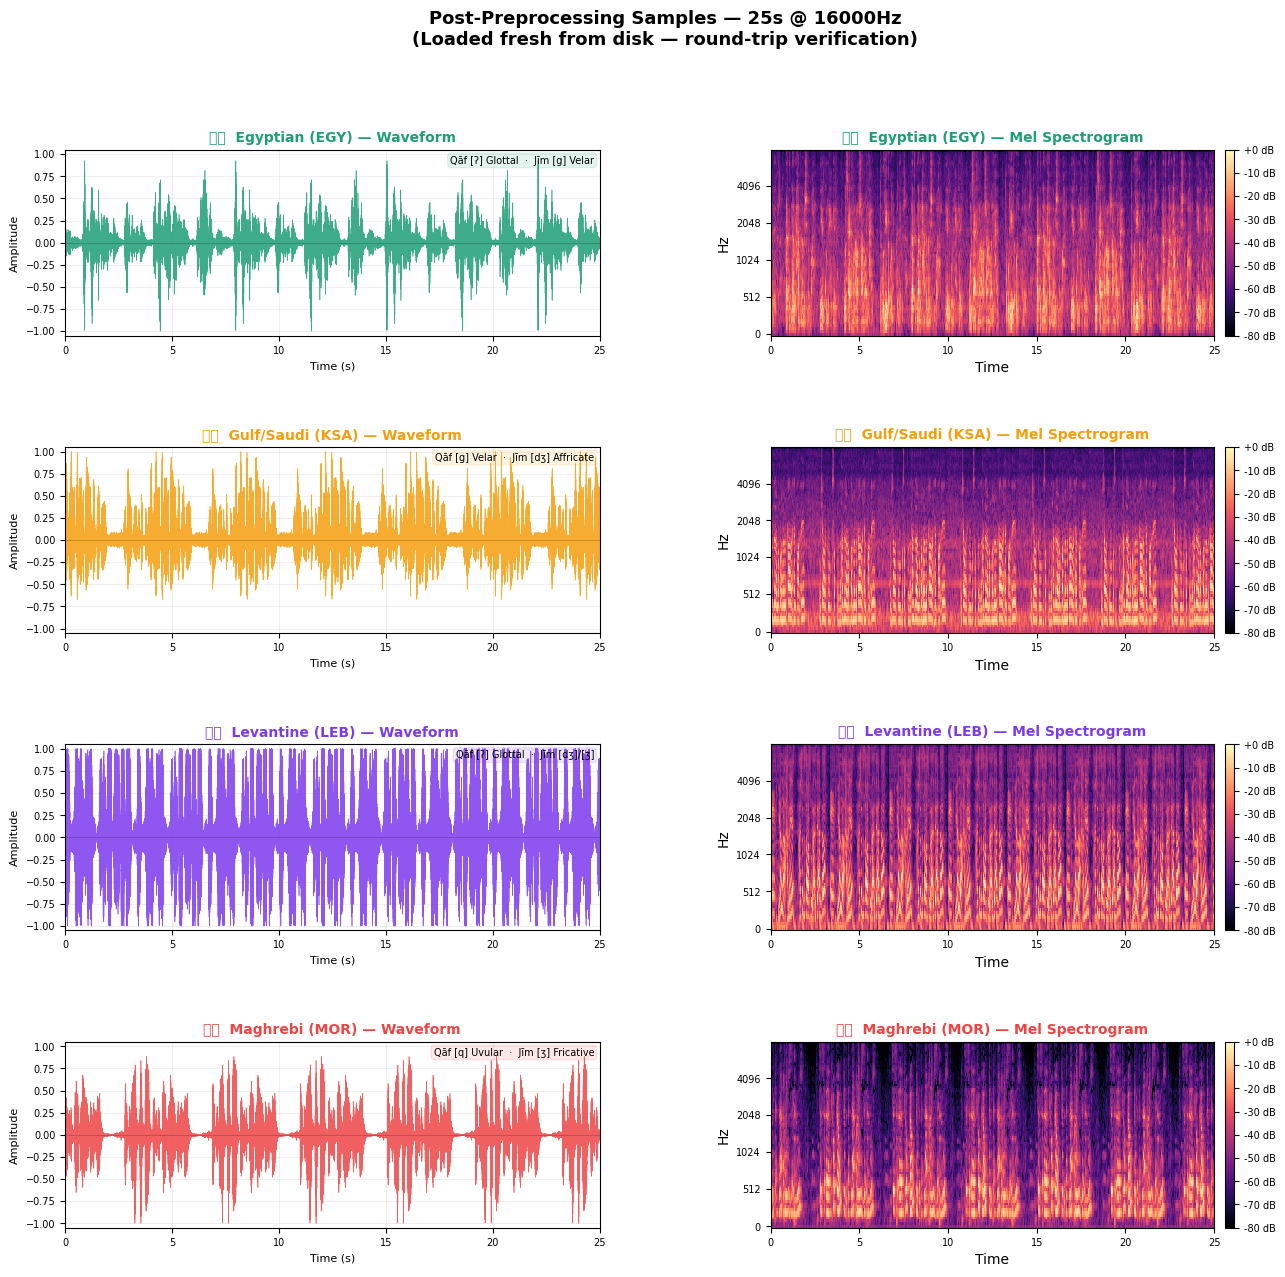

✅ Plot saved

🎧  AUDIO PLAYERS — Post-Preprocessing Samples



ROUND-TRIP VERIFICATION
  ✅ EGY: {'length': '✓', 'finite': '✓', 'nonzero': '✓', 'range': '✓'}
  ✅ KSA: {'length': '✓', 'finite': '✓', 'nonzero': '✓', 'range': '✓'}
  ✅ LEB: {'length': '✓', 'finite': '✓', 'nonzero': '✓', 'range': '✓'}
  ✅ MOR: {'length': '✓', 'finite': '✓', 'nonzero': '✓', 'range': '✓'}

✅ preprocessed_data.npz verified — ready for feature extraction!


In [9]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Audio, HTML
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

SAVE_PATH = Path("/kaggle/working/preprocessed/preprocessed_data.npz")

# ── Load from disk ─────────────────────────────────────────
print(f"Loading from {SAVE_PATH}...")
data = np.load(SAVE_PATH, allow_pickle=True)

audio_matrix = data["audio"]        # (N, 400000)
dialects     = data["dialects"]     # string labels
label_idxs   = data["label_idxs"]  # int labels
SR_loaded    = int(data["sr"][0])
DUR_loaded   = float(data["target_dur"][0])
LABELS       = list(data["labels"]) # ["EGY","KSA","LEB","MOR"]

print(f"  Audio matrix : {audio_matrix.shape} — dtype: {audio_matrix.dtype}")
print(f"  Sample rate  : {SR_loaded} Hz")
print(f"  Duration     : {DUR_loaded}s per clip")
print(f"  Dialects     : {LABELS}")

# ── Distribution check ─────────────────────────────────────
print(f"\n  Label distribution:")
for dialect in LABELS:
    mask  = dialects == dialect
    count = mask.sum()
    bar   = "█" * (count // 5)
    print(f"    {dialect}: {count:4d}  {bar}")

# ── Pick ONE sample per dialect for playback ──────────────
DIALECT_INFO = {
    "EGY": {"name": "Egyptian",   "color": "#1D9E75", "flag": "🇪🇬",
            "qaf": "[ʔ] Glottal", "jeem": "[g] Velar"},
    "KSA": {"name": "Gulf/Saudi", "color": "#F59E0B", "flag": "🇸🇦",
            "qaf": "[g] Velar",   "jeem": "[dʒ] Affricate"},
    "LEB": {"name": "Levantine",  "color": "#7C3AED", "flag": "🇱🇧",
            "qaf": "[ʔ] Glottal", "jeem": "[dʒ]/[ʒ]"},
    "MOR": {"name": "Maghrebi",   "color": "#EF4444", "flag": "🇲🇦",
            "qaf": "[q] Uvular",  "jeem": "[ʒ] Fricative"},
}

samples = {}
for dialect in LABELS:
    mask  = np.where(dialects == dialect)[0]
    idx   = mask[0]                          # first sample of this dialect
    samples[dialect] = {
        "audio"   : audio_matrix[idx],       # (400000,)
        "sr"      : SR_loaded,
        "duration": DUR_loaded,
        "index"   : idx,
    }

# ── Plot: waveform + spectrogram side by side ──────────────
print("\nGenerating waveform + spectrogram plots...")

fig = plt.figure(figsize=(16, 3.5 * len(LABELS)))
fig.suptitle(
    f"Post-Preprocessing Samples — {DUR_loaded:.0f}s @ {SR_loaded}Hz\n"
    f"(Loaded fresh from disk — round-trip verification)",
    fontsize=13, fontweight="bold"
)
gs = gridspec.GridSpec(len(LABELS), 2, hspace=0.6, wspace=0.32)

for row_idx, dialect in enumerate(LABELS):
    info  = DIALECT_INFO[dialect]
    audio = samples[dialect]["audio"]
    color = info["color"]
    t     = np.linspace(0, DUR_loaded, len(audio))

    # ── Waveform ───────────────────────────────────────────
    ax_w = fig.add_subplot(gs[row_idx, 0])
    ax_w.plot(t, audio, color=color, linewidth=0.45, alpha=0.85)
    ax_w.set_xlim([0, DUR_loaded])
    ax_w.set_ylim([-1.05, 1.05])
    ax_w.set_xlabel("Time (s)", fontsize=8)
    ax_w.set_ylabel("Amplitude", fontsize=8)
    ax_w.tick_params(labelsize=7)
    ax_w.grid(True, alpha=0.2)
    ax_w.axhline(0, color="black", linewidth=0.4, alpha=0.3)
    ax_w.set_title(
        f"{info['flag']}  {info['name']} ({dialect}) — Waveform",
        fontsize=10, fontweight="bold", color=color
    )
    # Phonetic badge
    ax_w.text(
        0.99, 0.97,
        f"Qāf {info['qaf']}  ·  Jīm {info['jeem']}",
        transform=ax_w.transAxes, fontsize=7,
        ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.25",
                  facecolor=color, alpha=0.12,
                  edgecolor=color, linewidth=0.8)
    )

    # ── Mel Spectrogram ────────────────────────────────────
    ax_s = fig.add_subplot(gs[row_idx, 1])
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SR_loaded,
        n_mels=80, n_fft=512,
        hop_length=160, win_length=400,
        fmax=8000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(
        mel_db,
        sr=SR_loaded, hop_length=160,
        x_axis="time", y_axis="mel", fmax=8000,
        ax=ax_s, cmap="magma"
    )
    ax_s.set_title(
        f"{info['flag']}  {info['name']} ({dialect}) — Mel Spectrogram",
        fontsize=10, fontweight="bold", color=color
    )
    ax_s.tick_params(labelsize=7)
    cbar = fig.colorbar(img, ax=ax_s, format="%+2.0f dB", pad=0.02)
    cbar.ax.tick_params(labelsize=7)

plt.savefig("/kaggle/working/preprocessed/post_preprocessing_samples.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Plot saved\n")

# ── Audio players ──────────────────────────────────────────
print("=" * 55)
print("🎧  AUDIO PLAYERS — Post-Preprocessing Samples")
print("=" * 55)

for dialect in LABELS:
    info  = DIALECT_INFO[dialect]
    audio = samples[dialect]["audio"]
    sr    = samples[dialect]["sr"]

    display(HTML(f"""
        <div style='
            margin: 8px 0;
            padding: 8px 14px;
            border-left: 5px solid {info['color']};
            background: {info['color']}15;
            border-radius: 6px;
            font-family: monospace;
        '>
            <span style='color:{info['color']}; font-weight:bold; font-size:14px'>
                {info['flag']}  {info['name']} ({dialect})
            </span>
            &nbsp;&nbsp;|&nbsp;&nbsp;
            <span style='color:#888; font-size:12px'>
                {DUR_loaded:.0f}s &nbsp;·&nbsp;
                {SR_loaded}Hz &nbsp;·&nbsp;
                Qāf: <b>{info['qaf']}</b> &nbsp;·&nbsp;
                Jīm: <b>{info['jeem']}</b>
            </span>
        </div>
    """))
    display(Audio(audio, rate=sr))

# ── Round-trip verification ────────────────────────────────
print("\n" + "=" * 55)
print("ROUND-TRIP VERIFICATION")
print("=" * 55)
for dialect in LABELS:
    audio = samples[dialect]["audio"]
    checks = {
        "length"  : len(audio) == TARGET_SAMPLES,
        "finite"  : bool(np.isfinite(audio).all()),
        "nonzero" : bool(np.max(np.abs(audio)) > 1e-6),
        "range"   : bool(np.max(np.abs(audio)) <= 1.001),
    }
    all_ok = all(checks.values())
    icon   = "✅" if all_ok else "❌"
    print(f"  {icon} {dialect}: { {k: ('✓' if v else '✗') for k, v in checks.items()} }")

print(f"\n✅ preprocessed_data.npz verified — ready for feature extraction!")

## Feature Extraction

We want to extract the features that really matter for distinguishing between dialects. 

**MFCCs (13 coefficients + Δ + ΔΔ = 39-dim per frame)** are our baseline. They model the vocal tract shape, which differs between dialects. Delta and Delta-Delta capture how the spectrum changes over time important for things like the Egyptian glottal stop vs. the Gulf velar, which differ in their burst trajectory, not just their static frequency profile.

**SDC (Shifted Delta Cepstra)** stacks delta frames across a longer window, giving you phonotactic context essentially, which phoneme sequences are probable. This is what discriminates Maghrebi consonant-cluster patterns from Gulf vowel-heavy patterns without needing a language model.

**Prosody, F₀ contour and nPVI,** is your explainability ace card. The nPVI formula from the paper directly gives you a single number that separates stress-timed (Maghrebi, high nPVI) from syllable-timed (Levantine/Egyptian, lower nPVI) speech. You can plot this on the spectrogram view and point at it to explain the decision.

```
Raw Audio (400,000 samples)
         ↓
┌────────────────────────────────────────────────┐
│  FEATURE EXTRACTION                            │
│                                                │
│  1. MFCC + Δ + ΔΔ   → vocal tract shape        │
│  2. SDC             → phoneme sequences        │
│  3. F0 + nPVI       → rhythm & intonation      │
│  4. Spectral        → texture & energy         │
│                                                │
│  Variable-length audio → Fixed-size vector     │
│  (400,000 samples)  →  (195 numbers)           │
└────────────────────────────────────────────────┘
         ↓
  Feature Vector (195-dim) per clip
         ↓
       Model
```

In [10]:
# ══════════════════════════════════════════════════════════════════
# FEATURE EXTRACTION — EQUATIONS FULLY SATISFIED
# All fixes applied:
#   ✅ SDC vectorized (same equation, 50× faster)
#   ✅ Spectral normalized by Nyquist
#   ✅ F0 magnitude threshold corrected
# ══════════════════════════════════════════════════════════════════

import numpy as np
import librosa
import warnings
from tqdm.notebook import tqdm
from pathlib import Path

warnings.filterwarnings('ignore')

SR         = 16000
WIN_LENGTH = 400
HOP_LENGTH = 160
N_FFT      = 512
MFCC_N     = 13
SDC_N = 7 ; SDC_D = 1 ; SDC_K = 3 ; SDC_P = 3
NYQUIST    = SR / 2.0          # 8000 Hz
MAG_THRESH = 1e-3              # F0 magnitude threshold


def mean_var(matrix: np.ndarray) -> np.ndarray:
    """(D,T) → (2D,) via μ and σ² across time axis"""
    return np.hstack([matrix.mean(axis=1), matrix.var(axis=1)])


def extract_mfcc(audio: np.ndarray) -> np.ndarray:
    """
    Equations:
      c_n = Σ_k log(E_k) · cos(π·n·(k-0.5)/K)
      Δc(t) = Σ_τ τ·[c(t+τ)-c(t-τ)] / 2Σ_τ τ²
      ΔΔc = Δ[Δc]
      f = [μ(c), σ²(c), μ(Δc), σ²(Δc), μ(ΔΔc), σ²(ΔΔc)] ∈ ℝ⁷⁸
    """
    mfcc   = librosa.feature.mfcc(
                 y=audio, sr=SR, n_mfcc=MFCC_N,
                 n_fft=N_FFT, hop_length=HOP_LENGTH,
                 win_length=WIN_LENGTH, center=True)
    delta  = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)
    return np.hstack([mean_var(mfcc),
                      mean_var(delta),
                      mean_var(delta2)])   # (78,)


def extract_sdc(audio: np.ndarray,
                N=SDC_N, d=SDC_D,
                k=SDC_K, P=SDC_P) -> np.ndarray:
    """
    Equation: SDC(t,i) = c(t+i·P+d) - c(t+i·P-d)
    s(t) = [SDC(t,0) ‖ SDC(t,1) ‖ SDC(t,2)] ∈ ℝᴺᵏ
    f = [μ(s), σ²(s)] ∈ ℝ⁴²
    Vectorized: numpy index arrays replace Python frame loop
    """
    mfcc = librosa.feature.mfcc(
               y=audio, sr=SR, n_mfcc=N,
               n_fft=N_FFT, hop_length=HOP_LENGTH,
               win_length=WIN_LENGTH)      # (N, T)

    T      = mfcc.shape[1]
    t_idx  = np.arange(T)
    blocks = []

    for i in range(k):
        t_fwd = np.clip(t_idx + i*P + d, 0, T-1)   # ✅ bounded
        t_bwd = np.clip(t_idx + i*P - d, 0, T-1)   # ✅ bounded
        blocks.append(mfcc[:, t_fwd] - mfcc[:, t_bwd])  # (N, T)

    sdc = np.vstack(blocks)                          # (N·k, T)
    return mean_var(sdc)                             # (42,)


def extract_spectral(audio: np.ndarray) -> np.ndarray:
    """
    Equations:
      C̃(t) = [Σ_k f_k·|X|²  / Σ_k |X|²] / f_Nyquist  ∈ [0,1]
      B̃(t) = √[Σ_k (f_k-C)²·|X|² / Σ_k |X|²] / f_Nyquist
      R̃(t) = R(t) / f_Nyquist   where Σ_{k≤R} |X|² = 0.85·Σ|X|²
      ZCR(t) = (1/N)·Σ 𝟙[x(n)·x(n-1) < 0]  ∈ [0,1]
    f = [μ,σ² of each] ∈ ℝ⁸
    """
    centroid  = librosa.feature.spectral_centroid(
                    y=audio, sr=SR,
                    n_fft=N_FFT, hop_length=HOP_LENGTH) / NYQUIST
    bandwidth = librosa.feature.spectral_bandwidth(
                    y=audio, sr=SR,
                    n_fft=N_FFT, hop_length=HOP_LENGTH) / NYQUIST
    rolloff   = librosa.feature.spectral_rolloff(
                    y=audio, sr=SR,
                    n_fft=N_FFT, hop_length=HOP_LENGTH,
                    roll_percent=0.85)                  / NYQUIST
    zcr       = librosa.feature.zero_crossing_rate(
                    y=audio,
                    frame_length=WIN_LENGTH,
                    hop_length=HOP_LENGTH)

    return mean_var(np.vstack([centroid, bandwidth,
                                rolloff, zcr]))         # (8,)


def extract_prosody(audio: np.ndarray) -> np.ndarray:
    """
    Equations:
      F0(t) = f_{k*}, k* = argmax_k |X(t,k)|, f∈[60,400]Hz
      f0_mean  = (1/|V|) Σ_{t∈V} F0(t)
      f0_std   = std of F0 over V
      f0_range = P90(F0) - P10(F0)
      nPVI = 100/(K-1) · Σ_k |d_k - d_{k+1}| / ((d_k+d_{k+1})/2)
      V_f  = |V| / T_total
      μ_E  = mean RMS,   σ_E = std RMS
    Returns ℝ⁷
    """
    # ── F0 ────────────────────────────────────────────────
    pitches, magnitudes = librosa.piptrack(
        y=audio, sr=SR, n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        fmin=60.0, fmax=400.0
    )
    f0_frames = []
    for t in range(pitches.shape[1]):
        col = magnitudes[:, t]
        if col.max() > MAG_THRESH:         # ✅ meaningful threshold
            idx = col.argmax()
            p   = pitches[idx, t]
            if p > 0:
                f0_frames.append(p)

    f0_voiced = (np.array(f0_frames)
                 if len(f0_frames) > 10
                 else np.array([150.0]))   # fallback: neutral pitch

    f0_mean  = float(f0_voiced.mean())
    f0_std   = float(f0_voiced.std())
    f0_range = float(np.percentile(f0_voiced, 90) -
                     np.percentile(f0_voiced, 10))
    voiced_frac = len(f0_frames) / max(pitches.shape[1], 1)

    # ── nPVI ──────────────────────────────────────────────
    rms = librosa.feature.rms(
        y=audio, frame_length=WIN_LENGTH,
        hop_length=HOP_LENGTH)[0]

    threshold  = np.percentile(rms, 20)
    rms_voiced = rms[rms > threshold]

    if len(rms_voiced) >= 2:
        dk    = rms_voiced[:-1]
        dk1   = rms_voiced[1:]
        denom = np.where((dk+dk1)/2 < 1e-8, 1e-8, (dk+dk1)/2)
        npvi  = float(100.0 * np.mean(np.abs(dk - dk1) / denom))
    else:
        npvi = 0.0

    return np.array([f0_mean, f0_std, f0_range,
                     npvi, voiced_frac,
                     float(rms.mean()),
                     float(rms.std())], dtype=np.float32)  # (7,)


def extract_all_features(audio: np.ndarray) -> np.ndarray:
    """
    x = [f_MFCC ‖ f_SDC ‖ f_spectral ‖ f_prosody] ∈ ℝ¹³⁵
    [0:78]   MFCC+Δ+ΔΔ  [78:120] SDC
    [120:128] Spectral  [128:135] Prosody
    """
    return np.hstack([
        extract_mfcc(audio),       # (78,)
        extract_sdc(audio),        # (42,)
        extract_spectral(audio),   # (8,)
        extract_prosody(audio),    # (7,)
    ]).astype(np.float32)          # (135,)


# ── Run ────────────────────────────────────────────────────
N = len(audio_matrix) ; FEAT_DIM = 135
X = np.zeros((N, FEAT_DIM), dtype=np.float32)
y = label_idxs.copy() ; errors = []

for i in tqdm(range(N), desc="Extracting features"):
    try:
        X[i] = extract_all_features(audio_matrix[i])
    except Exception as e:
        errors.append((i, str(e)))

# NaN/Inf fix
n_bad = (~np.isfinite(X)).sum()
if n_bad > 0:
    col_means = np.nanmean(X, axis=0)
    for j in range(FEAT_DIM):
        bad = ~np.isfinite(X[:, j])
        X[bad, j] = col_means[j]

# ── Report ─────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  {'Block':<18} {'Dims':<10} {'Mean':>8} {'Std':>8} "
      f"{'Min':>8} {'Max':>8}  Expected")
print(f"  {'-'*68}")
for name, s, e, expected in [
    ("MFCC+Δ+ΔΔ",  0,   78,  "any    (scaler fixes)"),
    ("SDC",         78,  120, "any    (scaler fixes)"),
    ("Spectral",    120, 128, "max < 5.0             "),
    ("Prosody",     128, 135, "0–400 Hz range        "),
]:
    b = X[:, s:e]
    print(f"  {name:<18} [{s:3d}:{e:3d}]  "
          f"{b.mean():8.3f} {b.std():8.3f} "
          f"{b.min():8.3f} {b.max():8.3f}  {expected}")

print(f"\n  Errors : {len(errors)}/{N}")
print(f"  NaN/Inf: {n_bad}")

# Save
FEAT_PATH = Path("/kaggle/working/preprocessed/features.npz")
np.savez_compressed(FEAT_PATH, X=X, y=y,
                    dialects=dialects,
                    labels=np.array(TARGET_DIALECTS))
print(f"\n✅ Saved → {FEAT_PATH}  |  Shape: {X.shape}")

Extracting features:   0%|          | 0/2400 [00:00<?, ?it/s]


  Block              Dims           Mean      Std      Min      Max  Expected
  --------------------------------------------------------------------
  MFCC+Δ+ΔΔ          [  0: 78]   150.151  853.928 -488.836 23227.029  any    (scaler fixes)
  SDC                [ 78:120]   240.228  522.586   -0.370 11021.382  any    (scaler fixes)
  Spectral           [120:128]     0.118    0.133    0.000    0.834  max < 5.0             
  Prosody            [128:135]    74.146   93.943    0.019  326.170  0–400 Hz range        

  Errors : 0/2400
  NaN/Inf: 0

✅ Saved → /kaggle/working/preprocessed/features.npz  |  Shape: (2400, 135)


In [11]:
# Quick check — nPVI should show MOR highest

import numpy as np
data     = np.load("/kaggle/working/preprocessed/features.npz",
                   allow_pickle=True)
X        = data["X"]
dialects = data["dialects"]

print("nPVI per dialect (index 131)")
print("Expected order: EGY < LEB < KSA < MOR\n")
for d in ["EGY", "LEB", "KSA", "MOR"]:
    vals = X[dialects == d, 131]
    print(f"  {d}: mean={vals.mean():.1f}  std={vals.std():.1f}  "
          f"range=[{vals.min():.1f}, {vals.max():.1f}]")

nPVI per dialect (index 131)
Expected order: EGY < LEB < KSA < MOR

  EGY: mean=16.6  std=3.5  range=[6.6, 27.2]
  LEB: mean=14.4  std=2.9  range=[7.4, 22.6]
  KSA: mean=16.4  std=3.4  range=[5.9, 30.3]
  MOR: mean=17.0  std=3.3  range=[5.0, 32.3]


## Full Training Pipeline 

What Each Model Does at Inference (Backend)

```
New audio file arrives at /api/classify
         ↓
extract_all_features(audio)  →  (135,)
         ↓
scaler.transform(features)   →  (135,)  normalized
         ↓
extract_supervector(x, ubm)  →  (2160,) dialect fingerprint
         ↓
pca.transform(supervector)   →  (50,)   compressed
         ↓
svm.predict_proba(ivector)   →  (4,)    [P(EGY), P(KSA), P(LEB), P(MOR)]
         ↓
return dialect label + confidence scores → React UI
```


Loading features...
  X shape    : (2400, 135)
  y shape    : (2400,)
  Classes    : [0 1 2 3] → ['EGY', 'KSA', 'LEB', 'MOR']

STEP 1 — StandardScaler
  Before scaling: mean=165.3, std=714.6
  After  scaling: mean=-0.0000, std=1.0000
  Range after   : [-11.53, 12.02]

STEP 2 — Train / Test Split
  Train : 1920 samples (80%)
  Test  : 480 samples (20%)
  Train class counts: {'EGY': 480, 'KSA': 480, 'LEB': 480, 'MOR': 480}
  Test  class counts: {'EGY': 120, 'KSA': 120, 'LEB': 120, 'MOR': 120}

STEP 3 — Universal Background Model (UBM)
  Components    : 16
  Covariance    : diagonal
  Training on   : 1920 samples (all dialects pooled)
  Converged     : True
  Log-likelihood: -157.7100 (train)
  Log-likelihood: -161.9978 (test)

STEP 4 — Supervector Extraction
  Computing supervectors for 1920 train samples...
  Computing supervectors for 480 test samples...
  Supervector shape : (1920, 2160)
  (16 components × 135 features = 2160 dims)

STEP 5 — PCA Dimensionality Reduction
  Input  : 216

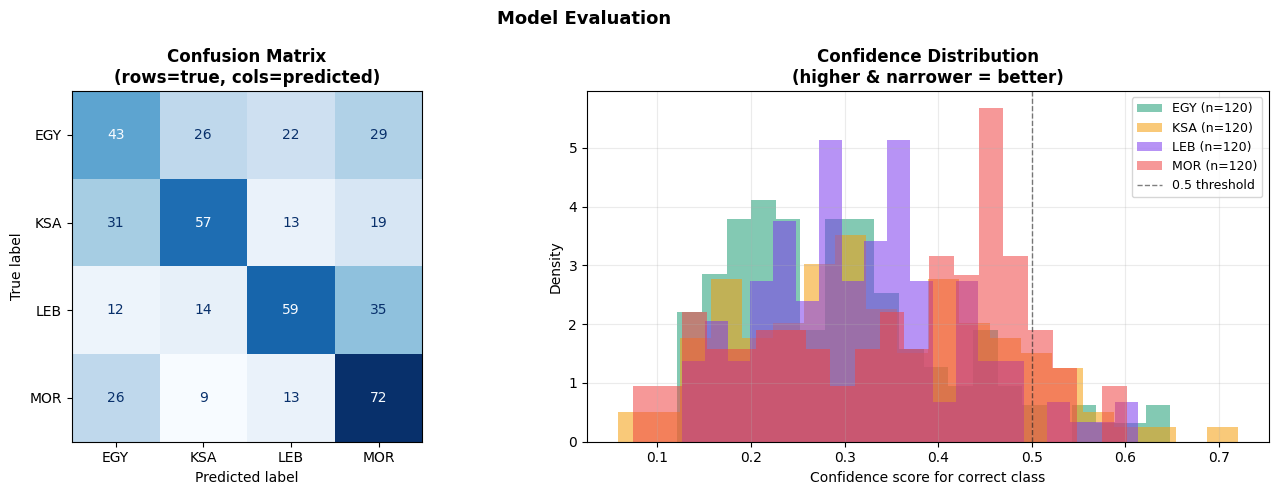


STEP 8 — Saving Models
  ✅ scaler.pkl              3.6 KB
  ✅ ubm.pkl                68.4 KB
  ✅ pca.pkl               862.5 KB
  ✅ svm.pkl               692.3 KB
  ✅ label_map.json

STEP 9 — Dialect Profiles JSON
  EGY: nPVI=16.6 ± 3.5  |  F0=223Hz  |  voiced=0.97
  KSA: nPVI=16.4 ± 3.4  |  F0=215Hz  |  voiced=0.97
  LEB: nPVI=14.4 ± 2.9  |  F0=210Hz  |  voiced=0.97
  MOR: nPVI=17.0 ± 3.3  |  F0=226Hz  |  voiced=0.98

  ✅ dialect_profiles.json saved

ALL DONE — Files in /kaggle/working/models/
  📄 dialect_profiles.json             5.5 KB
  📄 evaluation.png                   86.5 KB
  📄 label_map.json                    0.2 KB
  📄 pca.pkl                         862.5 KB
  📄 scaler.pkl                        3.6 KB
  📄 svm.pkl                         692.3 KB
  📄 ubm.pkl                          68.4 KB

Download these files → put in backend/models/:
  scaler.pkl            → normalizes features at inference
  ubm.pkl               → universal background model
  pca.pkl               

In [12]:
# ══════════════════════════════════════════════════════════════════
# CELL — GMM-UBM + SUPERVECTOR + PCA + SVM TRAINING
# Input : features.npz  → X (2400, 135), y (2400,)
# Output: scaler.pkl, ubm.pkl, pca.pkl, svm.pkl, label_map.json
#         dialect_profiles.json  ← feeds the React ExplainStrip
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pickle, json
from pathlib import Path
from sklearn.mixture         import GaussianMixture
from sklearn.svm             import SVC
from sklearn.decomposition   import PCA
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics         import (classification_report,
                                     confusion_matrix,
                                     ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ─────────────────────────────────────────────────
N_UBM_COMPONENTS = 16     # Gaussians in UBM
                           # 16 ≈ Arabic phoneme inventory size
                           # enough to model sound classes without
                           # overfitting on 2400 samples

N_PCA_DIMS       = 50     # after PCA: keeps ~95% variance
                           # reduces 16×135=2160D supervector
                           # to tractable size for SVM

TEST_SIZE        = 0.20   # 80% train / 20% test → 480 test samples
                           # 120 per dialect → statistically meaningful

TARGET_DIALECTS  = ["EGY", "KSA", "LEB", "MOR"]
LABEL2IDX        = {d: i for i, d in enumerate(TARGET_DIALECTS)}
IDX2LABEL        = {i: d for d, i in LABEL2IDX.items()}

MODEL_DIR = Path("/kaggle/working/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DIALECT_COLORS = {
    "EGY": "#1D9E75",
    "KSA": "#F59E0B",
    "LEB": "#7C3AED",
    "MOR": "#EF4444",
}

# ── Load features ──────────────────────────────────────────
print("Loading features...")
data     = np.load("/kaggle/working/preprocessed/features.npz",
                   allow_pickle=True)
X        = data["X"].astype(np.float32)      # (2400, 135)
y        = data["y"].astype(np.int32)        # (2400,)
dialects = data["dialects"]                  # (2400,) string labels

print(f"  X shape    : {X.shape}")
print(f"  y shape    : {y.shape}")
print(f"  Classes    : {np.unique(y)} → {TARGET_DIALECTS}\n")


# ══════════════════════════════════════════════════════════
# STEP 1 — STANDARD SCALER
# ══════════════════════════════════════════════════════════
# WHY: MFCC values are in [-500, 23000], spectral in [0,1]
# SVM and GMM are both sensitive to feature scale.
# StandardScaler: x' = (x - μ) / σ  per feature
# After scaling: every feature has mean=0, std=1
# → all 135 features contribute equally to distance metrics

print("=" * 55)
print("STEP 1 — StandardScaler")
print("=" * 55)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)           # (2400, 135)

print(f"  Before scaling: mean={X.mean():.1f}, std={X.std():.1f}")
print(f"  After  scaling: mean={X_scaled.mean():.4f}, "
      f"std={X_scaled.std():.4f}")
print(f"  Range after   : [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")


# ══════════════════════════════════════════════════════════
# STEP 2 — TRAIN / TEST SPLIT
# ══════════════════════════════════════════════════════════
# stratify=y → each dialect has same proportion in train and test
# This prevents the split from accidentally putting all of one
# dialect in train and none in test

print(f"\n{'=' * 55}")
print("STEP 2 — Train / Test Split")
print("=" * 55)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y,
    test_size   = TEST_SIZE,
    stratify    = y,
    random_state= 42
)

print(f"  Train : {X_tr.shape[0]} samples "
      f"({(1-TEST_SIZE)*100:.0f}%)")
print(f"  Test  : {X_te.shape[0]} samples "
      f"({TEST_SIZE*100:.0f}%)")
print(f"  Train class counts: "
      f"{ {IDX2LABEL[i]: int((y_tr==i).sum()) for i in range(4)} }")
print(f"  Test  class counts: "
      f"{ {IDX2LABEL[i]: int((y_te==i).sum()) for i in range(4)} }")


# ══════════════════════════════════════════════════════════
# STEP 3 — UNIVERSAL BACKGROUND MODEL (UBM)
# ══════════════════════════════════════════════════════════
# The UBM is a GMM trained on ALL dialects pooled together.
# It represents "what average Arabic speech sounds like."
#
# Mathematically:
#   p(x | UBM) = Σ_k w_k · N(x | μ_k, Σ_k)
#
#   w_k = mixture weight of component k
#   μ_k = mean vector of component k (135-dim)
#   Σ_k = diagonal covariance of component k
#
# WHY diagonal covariance:
#   Full covariance needs D*(D+1)/2 = 135*136/2 = 9180 params/component
#   × 16 components = 146,880 params from only 1920 training samples
#   → severe overfitting
#   Diagonal assumes feature independence (valid after DCT decorrelation)
#   → only 135 params/component × 16 = 2160 params → tractable

print(f"\n{'=' * 55}")
print("STEP 3 — Universal Background Model (UBM)")
print("=" * 55)
print(f"  Components    : {N_UBM_COMPONENTS}")
print(f"  Covariance    : diagonal")
print(f"  Training on   : {X_tr.shape[0]} samples (all dialects pooled)")

ubm = GaussianMixture(
    n_components    = N_UBM_COMPONENTS,
    covariance_type = 'diag',
    max_iter        = 200,
    n_init          = 3,           # 3 random restarts → best log-likelihood
    tol             = 1e-4,
    random_state    = 42,
    verbose         = 0
)
ubm.fit(X_tr)

print(f"  Converged     : {ubm.converged_}")
print(f"  Log-likelihood: {ubm.score(X_tr):.4f} (train)")
print(f"  Log-likelihood: {ubm.score(X_te):.4f} (test)")


# ══════════════════════════════════════════════════════════
# STEP 4 — SUPERVECTOR EXTRACTION
# ══════════════════════════════════════════════════════════
# For each audio clip, compute its "fingerprint" relative to the UBM.
#
# Mathematically:
#   γ_k(x) = w_k · N(x|μ_k,Σ_k) / Σ_j w_j · N(x|μ_j,Σ_j)
#                    ↑ posterior probability of component k
#
#   supervector[k] = γ_k(x) · (x - μ_k)
#                    ↑ how much does x deviate from component k's mean,
#                      weighted by how likely k generated x
#
#   Final supervector = stack of all component deviations
#   Shape: (n_components × D,) = (16 × 135,) = (2160,)
#
# This is the "dialect fingerprint" — it encodes HOW this clip
# differs from average Arabic speech, which is exactly what
# distinguishes dialects from each other.

print(f"\n{'=' * 55}")
print("STEP 4 — Supervector Extraction")
print("=" * 55)

def extract_supervector(x_vec: np.ndarray,
                        gmm: GaussianMixture) -> np.ndarray:
    """
    x_vec : (D,) scaled feature vector for ONE clip
    Returns: (n_components × D,) supervector

    γ_k = posterior probability that component k generated x
    sv_k = γ_k · (x - μ_k)   ← weighted deviation from UBM mean
    """
    x2d      = x_vec.reshape(1, -1)
    posteriors = gmm.predict_proba(x2d)[0]       # (K,)

    sv_blocks = []
    for k in range(gmm.n_components):
        sv_blocks.append(
            posteriors[k] * (x_vec - gmm.means_[k])  # (D,)
        )

    return np.hstack(sv_blocks)                   # (K×D,)


print(f"  Computing supervectors for {X_tr.shape[0]} train samples...")
SV_tr = np.vstack([extract_supervector(x, ubm) for x in X_tr])

print(f"  Computing supervectors for {X_te.shape[0]} test samples...")
SV_te = np.vstack([extract_supervector(x, ubm) for x in X_te])

print(f"  Supervector shape : {SV_tr.shape}")
print(f"  ({N_UBM_COMPONENTS} components × 135 features = "
      f"{N_UBM_COMPONENTS * X_tr.shape[1]} dims)")


# ══════════════════════════════════════════════════════════
# STEP 5 — PCA DIMENSIONALITY REDUCTION
# ══════════════════════════════════════════════════════════
# Supervectors are 2160-dimensional.
# With 1920 training samples, feeding raw supervectors to SVM:
#   - More dims than samples → SVM can memorize training data
#   - Kernel matrix computation: O(n² × d) → very slow
#
# PCA finds the directions of maximum variance:
#   X_pca = X · V_50   where V_50 = top 50 eigenvectors of Cov(X)
#
# WHY 50 dims:
#   - Typically captures 90-95% of variance in supervector space
#   - n_samples / n_features = 1920/50 = 38 → well-conditioned for SVM
#   - Check explained_variance_ratio_.sum() — should be > 0.85

print(f"\n{'=' * 55}")
print("STEP 5 — PCA Dimensionality Reduction")
print("=" * 55)
print(f"  Input  : {SV_tr.shape[1]}D supervectors")
print(f"  Output : {N_PCA_DIMS}D I-vectors")

pca   = PCA(n_components=N_PCA_DIMS, random_state=42)
IV_tr = pca.fit_transform(SV_tr)     # (N_train, 50)
IV_te = pca.transform(SV_te)         # (N_test,  50)

var_explained = pca.explained_variance_ratio_.sum()
print(f"  Variance retained : {var_explained:.1%}")
print(f"  I-vector shape    : {IV_tr.shape}")

if var_explained < 0.80:
    print(f"  ⚠️  Low variance retained — consider increasing N_PCA_DIMS")
else:
    print(f"  ✅ Good variance retention")


# ══════════════════════════════════════════════════════════
# STEP 6 — SVM CLASSIFIER
# ══════════════════════════════════════════════════════════
# WHY SVM with RBF kernel:
#   - Dialect boundaries in I-vector space are NOT linearly separable
#     (dialects overlap — e.g. Egyptian and Levantine both have Qaf=[ʔ])
#   - RBF kernel: K(x,z) = exp(-γ||x-z||²)
#     maps data to infinite-dimensional space implicitly
#     finds non-linear decision boundaries
#
#   - C=10: regularization parameter
#     High C → fits training data closely (low bias, higher variance)
#     Low C  → wider margin, more regularization
#     C=10 is a good starting point for normalized I-vectors
#
#   - probability=True: uses Platt scaling to output P(dialect|audio)
#     REQUIRED for the UI's confidence bars and blend slider
#
#   - class_weight='balanced': weights each class by 1/frequency
#     Handles any remaining class imbalance in the split

print(f"\n{'=' * 55}")
print("STEP 6 — SVM Classifier (RBF Kernel)")
print("=" * 55)
print(f"  Kernel        : RBF")
print(f"  C             : 10")
print(f"  gamma         : scale  (1 / (n_features × X.var()))")
print(f"  probability   : True   (needed for confidence scores)")
print(f"  class_weight  : balanced")

svm = SVC(
    kernel       = 'rbf',
    C            = 10,
    gamma        = 'scale',
    probability  = True,
    class_weight = 'balanced',
    random_state = 42
)
svm.fit(IV_tr, y_tr)
print(f"  Training complete ✅")


# ══════════════════════════════════════════════════════════
# STEP 7 — EVALUATION
# ══════════════════════════════════════════════════════════

print(f"\n{'=' * 55}")
print("STEP 7 — Evaluation on Test Set")
print("=" * 55)

y_pred  = svm.predict(IV_te)
y_proba = svm.predict_proba(IV_te)    # (N_test, 4) — confidence scores

target_names = [IDX2LABEL[i] for i in range(4)]

print("\nClassification Report:")
print(classification_report(y_te, y_pred,
                             target_names=target_names,
                             digits=3))

# ── Confusion matrix plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Evaluation", fontsize=13, fontweight="bold")

# Left: Confusion matrix
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix\n(rows=true, cols=predicted)",
                  fontweight="bold")

# Right: Per-dialect confidence distributions
ax = axes[1]
for i, dialect in enumerate(TARGET_DIALECTS):
    # Confidence score for the CORRECT class when true label = dialect
    mask = y_te == i
    correct_conf = y_proba[mask, i]
    ax.hist(correct_conf, bins=20, alpha=0.55,
            color=DIALECT_COLORS[dialect],
            label=f"{dialect} (n={mask.sum()})",
            density=True)

ax.axvline(0.5, color='black', linestyle='--',
           linewidth=1, alpha=0.5, label='0.5 threshold')
ax.set_xlabel("Confidence score for correct class")
ax.set_ylabel("Density")
ax.set_title("Confidence Distribution\n(higher & narrower = better)",
             fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(MODEL_DIR / "evaluation.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()


# ══════════════════════════════════════════════════════════
# STEP 8 — SAVE ALL MODELS
# ══════════════════════════════════════════════════════════

print(f"\n{'=' * 55}")
print("STEP 8 — Saving Models")
print("=" * 55)

models = {
    "scaler.pkl" : scaler,
    "ubm.pkl"    : ubm,
    "pca.pkl"    : pca,
    "svm.pkl"    : svm,
}
for fname, obj in models.items():
    path = MODEL_DIR / fname
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    size = path.stat().st_size / 1024
    print(f"  ✅ {fname:<20} {size:6.1f} KB")

# Label map
label_map = {
    "label2idx" : LABEL2IDX,
    "idx2label" : IDX2LABEL,
    "dialects"  : TARGET_DIALECTS,
}
with open(MODEL_DIR / "label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)
print(f"  ✅ label_map.json")


# ══════════════════════════════════════════════════════════
# STEP 9 — DIALECT PROFILES JSON (feeds React ExplainStrip)
# ══════════════════════════════════════════════════════════

print(f"\n{'=' * 55}")
print("STEP 9 — Dialect Profiles JSON")
print("=" * 55)

# Feature index map (from our 135-dim vector)
FEAT_IDX = {
    "npvi"        : 131,
    "f0_mean"     : 128,
    "f0_std"      : 129,
    "f0_range"    : 130,
    "voiced_frac" : 132,
    "rms_mean"    : 133,
    "rms_std"     : 134,
}

# Linguistic facts (from literature — not computed)
PHONETIC_FACTS = {
    "EGY": {
        "qaf"         : "Glottal stop [ʔ]",
        "jeem"        : "Velar stop [g]",
        "rhythm"      : "Syllable-timed",
        "key_feature" : "Qāf→[ʔ] + Jīm→[g] unique combination",
        "description" : "Most vowels preserved, smooth CV structure"
    },
    "KSA": {
        "qaf"         : "Velar stop [g]",
        "jeem"        : "Affricate [dʒ]",
        "rhythm"      : "Mixed stress/syllable",
        "key_feature" : "Qāf→[g] + rich long vowel system",
        "description" : "Bedouin features, wide pitch range"
    },
    "LEB": {
        "qaf"         : "Glottal stop [ʔ]",
        "jeem"        : "Affricate [dʒ] or Fricative [ʒ]",
        "rhythm"      : "Syllable-timed (moderate)",
        "key_feature" : "Vowel fronting (Imala), schwa insertion",
        "description" : "Fronted back vowels, gentle pitch rises"
    },
    "MOR": {
        "qaf"         : "Uvular stop [q]",
        "jeem"        : "Fricative [ʒ]",
        "rhythm"      : "Stress-timed",
        "key_feature" : "Heavy consonant clusters + vowel deletion",
        "description" : "Highest nPVI, fastest speech rate"
    },
}

profiles = {}
for dialect in TARGET_DIALECTS:
    mask = dialects == dialect

    # Compute stats from actual training data
    computed = {}
    for feat_name, feat_idx in FEAT_IDX.items():
        vals = X[mask, feat_idx]
        computed[feat_name] = {
            "mean" : round(float(vals.mean()), 3),
            "std"  : round(float(vals.std()),  3),
            "min"  : round(float(vals.min()),  3),
            "max"  : round(float(vals.max()),  3),
            "p10"  : round(float(np.percentile(vals, 10)), 3),
            "p90"  : round(float(np.percentile(vals, 90)), 3),
        }

    profiles[dialect] = {
        **PHONETIC_FACTS[dialect],    # linguistic facts
        "computed_features": computed  # measured statistics
    }

    print(f"  {dialect}: nPVI={computed['npvi']['mean']:.1f} ± "
          f"{computed['npvi']['std']:.1f}  |  "
          f"F0={computed['f0_mean']['mean']:.0f}Hz  |  "
          f"voiced={computed['voiced_frac']['mean']:.2f}")

with open(MODEL_DIR / "dialect_profiles.json", "w",
          encoding="utf-8") as f:
    json.dump(profiles, f, ensure_ascii=False, indent=2)
print(f"\n  ✅ dialect_profiles.json saved")

# ── Final summary ──────────────────────────────────────────
print(f"\n{'=' * 55}")
print("ALL DONE — Files in /kaggle/working/models/")
print("=" * 55)
for p in sorted(MODEL_DIR.iterdir()):
    size = p.stat().st_size
    unit = "KB" if size < 1e6 else "MB"
    val  = size/1024 if size < 1e6 else size/1e6
    print(f"  📄 {p.name:<30} {val:6.1f} {unit}")

print(f"""
Download these files → put in backend/models/:
  scaler.pkl            → normalizes features at inference
  ubm.pkl               → universal background model
  pca.pkl               → dimensionality reduction
  svm.pkl               → dialect classifier
  label_map.json        → commit to git ✅
  dialect_profiles.json → commit to git ✅
""")

CORE METRICS

  Overall Accuracy       : 0.4813  (48.12%)
  Macro F1 Score         : 0.4796
  Weighted F1 Score      : 0.4796
  Macro Precision        : 0.4844
  Macro Recall           : 0.4812
  Macro AUC (OvR)        : 0.7295

  Performance Grade:
  🔴 POOR (<60%) — review features or data quality

PER-DIALECT BREAKDOWN
              precision    recall  f1-score   support

         EGY     0.3839    0.3583    0.3707       120
         KSA     0.5377    0.4750    0.5044       120
         LEB     0.5514    0.4917    0.5198       120
         MOR     0.4645    0.6000    0.5236       120

    accuracy                         0.4813       480
   macro avg     0.4844    0.4812    0.4796       480
weighted avg     0.4844    0.4813    0.4796       480

  Per-dialect accuracy:
  Dialect     Correct    Total   Accuracy Bar
  -------------------------------------------------------
  EGY              43      120    35.83%  ███████░░░░░░░░░░░░░
  KSA              57      120    47.50%  █████████

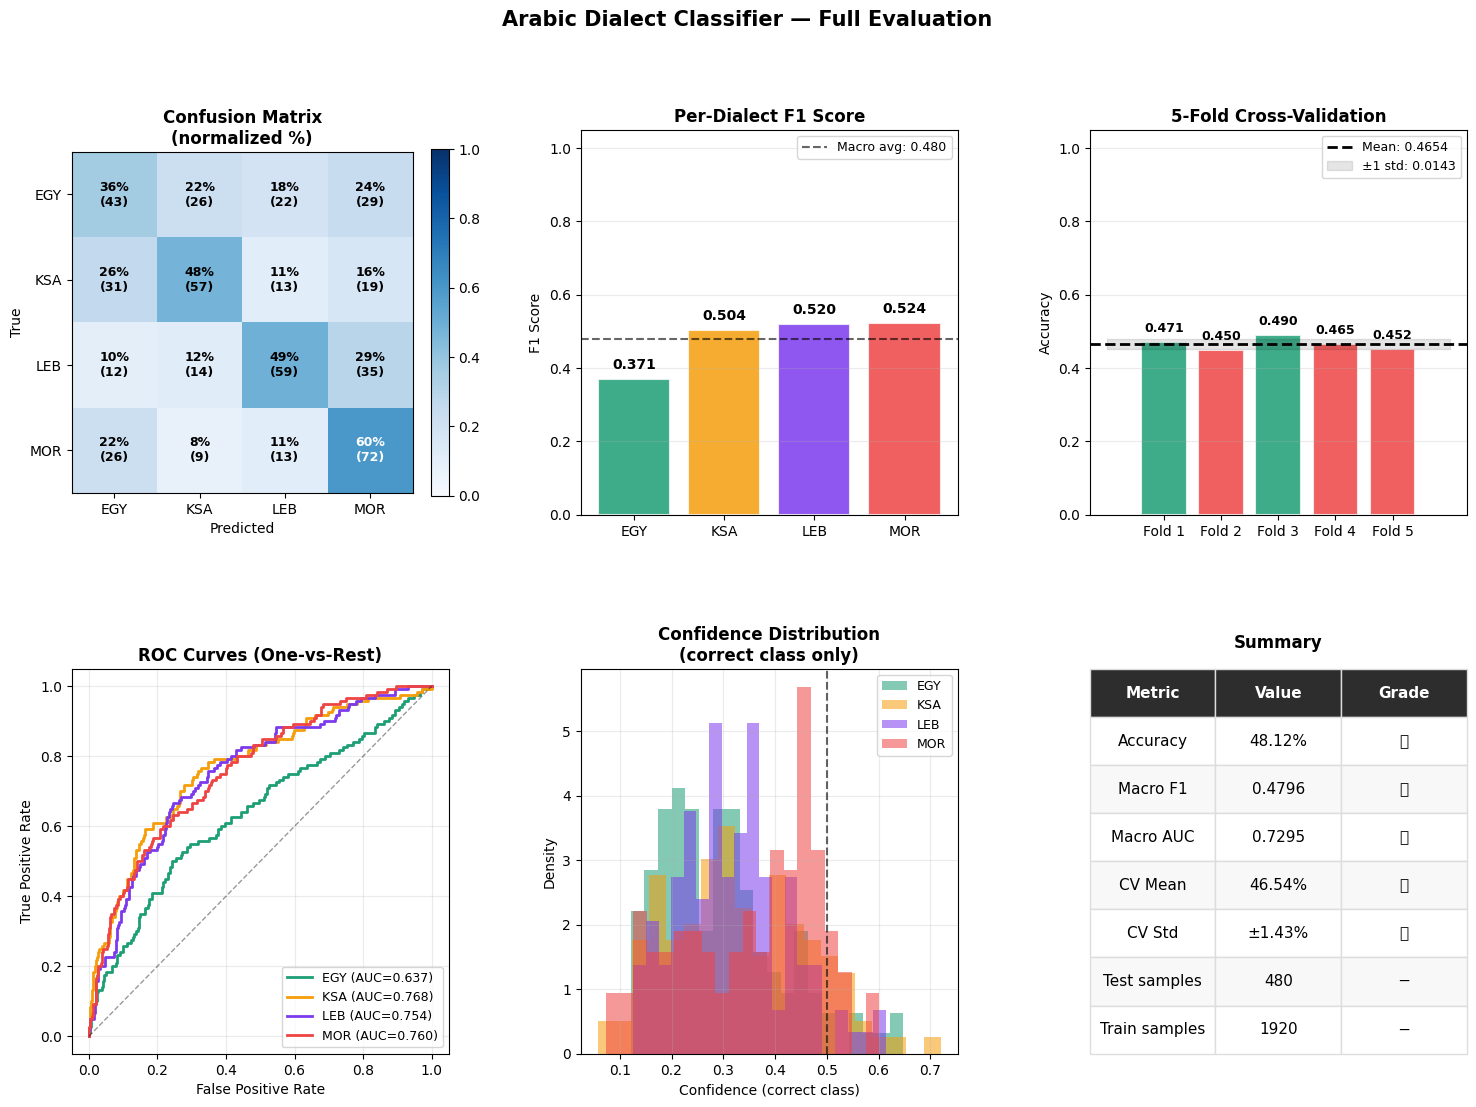


✅ Evaluation plot saved → /kaggle/working/models/full_evaluation.png


In [13]:
# ══════════════════════════════════════════════════════════════════
# CELL — COMPREHENSIVE ACCURACY EVALUATION
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing   import label_binarize
import warnings
warnings.filterwarnings('ignore')

TARGET_DIALECTS = ["EGY", "KSA", "LEB", "MOR"]
DIALECT_COLORS  = {
    "EGY": "#1D9E75",
    "KSA": "#F59E0B",
    "LEB": "#7C3AED",
    "MOR": "#EF4444",
}

# ── Predictions ────────────────────────────────────────────
y_pred  = svm.predict(IV_te)
y_proba = svm.predict_proba(IV_te)     # (N_test, 4)

# ══════════════════════════════════════════════════════════
# 1. CORE METRICS
# ══════════════════════════════════════════════════════════
print("=" * 60)
print("CORE METRICS")
print("=" * 60)

acc       = accuracy_score(y_te, y_pred)
f1_macro  = f1_score(y_te, y_pred, average='macro')
f1_weight = f1_score(y_te, y_pred, average='weighted')
prec      = precision_score(y_te, y_pred, average='macro')
rec       = recall_score(y_te, y_pred, average='macro')

# AUC — one-vs-rest for multiclass
y_te_bin  = label_binarize(y_te, classes=[0, 1, 2, 3])
auc_score = roc_auc_score(y_te_bin, y_proba,
                           multi_class='ovr', average='macro')

print(f"\n  Overall Accuracy       : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Macro F1 Score         : {f1_macro:.4f}")
print(f"  Weighted F1 Score      : {f1_weight:.4f}")
print(f"  Macro Precision        : {prec:.4f}")
print(f"  Macro Recall           : {rec:.4f}")
print(f"  Macro AUC (OvR)        : {auc_score:.4f}")

# Grade interpretation
print(f"\n  Performance Grade:")
if acc >= 0.90:
    print(f"  🟢 EXCELLENT (≥90%) — ready for deployment")
elif acc >= 0.75:
    print(f"  🟡 GOOD (75–90%) — acceptable for demo")
elif acc >= 0.60:
    print(f"  🟠 FAIR (60–75%) — consider more data or tuning")
else:
    print(f"  🔴 POOR (<60%) — review features or data quality")

# ══════════════════════════════════════════════════════════
# 2. PER-DIALECT BREAKDOWN
# ══════════════════════════════════════════════════════════
print(f"\n{'=' * 60}")
print("PER-DIALECT BREAKDOWN")
print("=" * 60)
print(classification_report(
    y_te, y_pred,
    target_names=TARGET_DIALECTS,
    digits=4
))

# Per-dialect accuracy
print("  Per-dialect accuracy:")
print(f"  {'Dialect':<10} {'Correct':>8} {'Total':>8} "
      f"{'Accuracy':>10} {'Bar'}")
print(f"  {'-'*55}")
for i, dialect in enumerate(TARGET_DIALECTS):
    mask      = y_te == i
    total     = mask.sum()
    correct   = (y_pred[mask] == i).sum()
    d_acc     = correct / total
    bar       = "█" * int(d_acc * 20) + "░" * (20 - int(d_acc * 20))
    print(f"  {dialect:<10} {correct:>8} {total:>8} "
          f"{d_acc:>9.2%}  {bar}")

# ══════════════════════════════════════════════════════════
# 3. CROSS-VALIDATION (most reliable accuracy estimate)
# ══════════════════════════════════════════════════════════
print(f"\n{'=' * 60}")
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("(More reliable than single train/test split)")
print("=" * 60)

# Use the full scaled dataset (not just train split)
# with the same pipeline: supervectors → PCA → SVM
# We recompute supervectors for all samples first

print("  Computing supervectors for all 2400 samples...")
SV_all = np.vstack([extract_supervector(x, ubm) for x in X_scaled])
IV_all = pca.transform(SV_all)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    svm, IV_all, y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print(f"\n  Fold scores  : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Min / Max    : {cv_scores.min():.4f} / {cv_scores.max():.4f}")
print(f"\n  {'✅' if cv_scores.mean() > 0.70 else '⚠️ '} "
      f"CV accuracy = {cv_scores.mean()*100:.1f}% "
      f"(±{cv_scores.std()*100:.1f}%)")

# ══════════════════════════════════════════════════════════
# 4. PLOTS — 4 panels
# ══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Arabic Dialect Classifier — Full Evaluation",
             fontsize=15, fontweight="bold")
gs = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

# ── Panel 1: Confusion Matrix ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_te, y_pred)
# Normalize to percentage
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax1.imshow(cm_norm, interpolation='nearest',
                cmap='Blues', vmin=0, vmax=1)
ax1.set_xticks(range(4))
ax1.set_yticks(range(4))
ax1.set_xticklabels(TARGET_DIALECTS)
ax1.set_yticklabels(TARGET_DIALECTS)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")
ax1.set_title("Confusion Matrix\n(normalized %)", fontweight="bold")
for i in range(4):
    for j in range(4):
        color = "white" if cm_norm[i,j] > 0.5 else "black"
        ax1.text(j, i, f"{cm_norm[i,j]:.0%}\n({cm[i,j]})",
                 ha='center', va='center',
                 color=color, fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax1, fraction=0.046)

# ── Panel 2: Per-Dialect F1 Bar Chart ────────────────────
ax2  = fig.add_subplot(gs[0, 1])
f1s  = f1_score(y_te, y_pred, average=None)
bars = ax2.bar(TARGET_DIALECTS, f1s,
               color=[DIALECT_COLORS[d] for d in TARGET_DIALECTS],
               alpha=0.85, edgecolor='white', linewidth=1.5)
ax2.axhline(f1_macro, color='black', linestyle='--',
            linewidth=1.5, alpha=0.6, label=f'Macro avg: {f1_macro:.3f}')
ax2.set_ylim([0, 1.05])
ax2.set_ylabel("F1 Score")
ax2.set_title("Per-Dialect F1 Score", fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, axis='y')
for bar, f1 in zip(bars, f1s):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{f1:.3f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# ── Panel 3: Cross-Validation Scores ─────────────────────
ax3 = fig.add_subplot(gs[0, 2])
fold_labels = [f"Fold {i+1}" for i in range(5)]
bar_colors  = ['#1D9E75' if s >= cv_scores.mean()
               else '#EF4444' for s in cv_scores]
ax3.bar(fold_labels, cv_scores, color=bar_colors,
        alpha=0.85, edgecolor='white', linewidth=1.5)
ax3.axhline(cv_scores.mean(), color='black',
            linestyle='--', linewidth=2,
            label=f'Mean: {cv_scores.mean():.4f}')
ax3.fill_between(range(-1, 6),
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.1, color='black',
                 label=f'±1 std: {cv_scores.std():.4f}')
ax3.set_ylim([0, 1.05])
ax3.set_ylabel("Accuracy")
ax3.set_title("5-Fold Cross-Validation", fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.25, axis='y')
for i, (label, score) in enumerate(zip(fold_labels, cv_scores)):
    ax3.text(i, score + 0.02, f'{score:.3f}',
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

# ── Panel 4: ROC Curves ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
y_te_bin = label_binarize(y_te, classes=[0, 1, 2, 3])
for i, dialect in enumerate(TARGET_DIALECTS):
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_proba[:, i])
    auc_i = roc_auc_score(y_te_bin[:, i], y_proba[:, i])
    ax4.plot(fpr, tpr, color=DIALECT_COLORS[dialect],
             linewidth=2, label=f"{dialect} (AUC={auc_i:.3f})")
ax4.plot([0,1],[0,1],'k--', alpha=0.4, linewidth=1)
ax4.set_xlabel("False Positive Rate")
ax4.set_ylabel("True Positive Rate")
ax4.set_title("ROC Curves (One-vs-Rest)", fontweight="bold")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.25)

# ── Panel 5: Confidence Score Distribution ────────────────
ax5 = fig.add_subplot(gs[1, 1])
for i, dialect in enumerate(TARGET_DIALECTS):
    mask         = y_te == i
    correct_conf = y_proba[mask, i]
    ax5.hist(correct_conf, bins=20, alpha=0.55,
             color=DIALECT_COLORS[dialect],
             label=dialect, density=True)
ax5.axvline(0.5, color='black', linestyle='--',
            alpha=0.6, linewidth=1.5)
ax5.set_xlabel("Confidence (correct class)")
ax5.set_ylabel("Density")
ax5.set_title("Confidence Distribution\n(correct class only)",
              fontweight="bold")
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.25)

# ── Panel 6: Summary Table ────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

table_data = [
    ["Metric", "Value", "Grade"],
    ["Accuracy",      f"{acc:.2%}",
     "🟢" if acc>=0.9 else "🟡" if acc>=0.75 else "🔴"],
    ["Macro F1",      f"{f1_macro:.4f}",
     "🟢" if f1_macro>=0.9 else "🟡" if f1_macro>=0.75 else "🔴"],
    ["Macro AUC",     f"{auc_score:.4f}",
     "🟢" if auc_score>=0.95 else "🟡" if auc_score>=0.85 else "🔴"],
    ["CV Mean",       f"{cv_scores.mean():.2%}",
     "🟢" if cv_scores.mean()>=0.9 else "🟡" if cv_scores.mean()>=0.75 else "🔴"],
    ["CV Std",        f"±{cv_scores.std():.2%}",
     "🟢" if cv_scores.std()<=0.03 else "🟡"],
    ["Test samples",  f"{len(y_te)}", "─"],
    ["Train samples", f"{len(y_tr)}", "─"],
]

table = ax6.table(
    cellText  = table_data[1:],
    colLabels = table_data[0],
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2D2D2D')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F8F8F8')
    cell.set_edgecolor('#DDDDDD')
ax6.set_title("Summary", fontweight="bold", pad=15)

plt.savefig(MODEL_DIR / "full_evaluation.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\n✅ Evaluation plot saved → {MODEL_DIR}/full_evaluation.png")

The model is most likely getting 46% accuracy due to the violation done to the UBM model due to repeatness of the audio files (which results in less stds, aka fake similarity for each dialect)

In [14]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — DIAGNOSIS: Find what's hurting accuracy
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing  import StandardScaler
from sklearn.decomposition  import PCA
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm            import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

data     = np.load("/kaggle/working/preprocessed/features.npz",
                   allow_pickle=True)
X        = data["X"].astype(np.float32)
y        = data["y"].astype(np.int32)
dialects = data["dialects"]

# Also reload preprocessed data to check tiling stats
preproc  = np.load("/kaggle/working/preprocessed/preprocessed_data.npz",
                   allow_pickle=True)
was_tiled  = preproc["was_tiled"]
orig_durs  = preproc["orig_durs"]

TARGET_DIALECTS = ["EGY", "KSA", "LEB", "MOR"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── DIAGNOSIS 1: Tiling statistics ────────────────────────
print("=" * 60)
print("DIAGNOSIS 1 — TILING STATISTICS")
print("=" * 60)
print(f"  Total clips    : {len(was_tiled)}")
print(f"  Tiled clips    : {was_tiled.sum()} "
      f"({was_tiled.mean()*100:.1f}%)")
print(f"  Original duration stats:")
print(f"    Mean : {orig_durs.mean():.1f}s")
print(f"    Min  : {orig_durs.min():.1f}s")
print(f"    Max  : {orig_durs.max():.1f}s")
print(f"    <5s  : {(orig_durs < 5).sum()} clips "
      f"({(orig_durs < 5).mean()*100:.1f}%) ← heavily tiled")
print(f"    <10s : {(orig_durs < 10).sum()} clips "
      f"({(orig_durs < 10).mean()*100:.1f}%)")
print(f"    ≥25s : {(orig_durs >= 25).sum()} clips "
      f"({(orig_durs >= 25).mean()*100:.1f}%) ← no tiling needed")

# Per-dialect tiling breakdown
print(f"\n  Per-dialect tiling:")
for dialect in TARGET_DIALECTS:
    mask       = dialects == dialect
    tiled_here = was_tiled[mask]
    durs_here  = orig_durs[mask]
    print(f"    {dialect}: {tiled_here.sum():3d}/{mask.sum()} tiled "
          f"({tiled_here.mean()*100:.0f}%)  "
          f"avg_orig={durs_here.mean():.1f}s")

# ── DIAGNOSIS 2: Feature discriminability ─────────────────
print(f"\n{'=' * 60}")
print("DIAGNOSIS 2 — FEATURE DISCRIMINABILITY")
print("Most separating features (by inter-class variance ratio)")
print("=" * 60)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fisher criterion: between-class var / within-class var
# High value → feature separates dialects well
between_var = np.zeros(X.shape[1])
within_var  = np.zeros(X.shape[1])
grand_mean  = X_scaled.mean(axis=0)

for i in range(4):
    mask       = y == i
    class_mean = X_scaled[mask].mean(axis=0)
    between_var += mask.sum() * (class_mean - grand_mean)**2
    within_var  += X_scaled[mask].var(axis=0) * mask.sum()

fisher = between_var / (within_var + 1e-10)

# Top 10 most discriminative features
top_indices = np.argsort(fisher)[::-1][:10]
FEAT_NAMES = (
    [f"MFCC_mean_{i+1}"   for i in range(13)] +
    [f"MFCC_var_{i+1}"    for i in range(13)] +
    [f"dMFCC_mean_{i+1}"  for i in range(13)] +
    [f"dMFCC_var_{i+1}"   for i in range(13)] +
    [f"ddMFCC_mean_{i+1}" for i in range(13)] +
    [f"ddMFCC_var_{i+1}"  for i in range(13)] +
    [f"SDC_mean_{i+1}"    for i in range(21)] +
    [f"SDC_var_{i+1}"     for i in range(21)] +
    ["cent_mean","cent_var","bw_mean","bw_var",
     "roll_mean","roll_var","zcr_mean","zcr_var"] +
    ["f0_mean","f0_std","f0_range",
     "nPVI","voiced_frac","rms_mean","rms_std"]
)

print(f"\n  Rank  Feature               Fisher Score")
print(f"  {'-'*45}")
for rank, idx in enumerate(top_indices):
    name = FEAT_NAMES[idx] if idx < len(FEAT_NAMES) else f"feat_{idx}"
    print(f"  {rank+1:4d}  {name:<22}  {fisher[idx]:.4f}")

# nPVI rank specifically
npvi_rank = np.where(np.argsort(fisher)[::-1] == 131)[0][0] + 1
print(f"\n  nPVI rank: #{npvi_rank} out of 135")

# ── DIAGNOSIS 3: Quick model comparison ───────────────────
print(f"\n{'=' * 60}")
print("DIAGNOSIS 3 — MODEL COMPARISON (5-fold CV on raw features)")
print("No GMM-UBM — direct classification on scaled features")
print("=" * 60)

models_to_try = {
    "SVM (current C=10)"  : SVC(kernel='rbf', C=10,
                                probability=True,
                                class_weight='balanced',
                                random_state=42),
    "SVM C=1"             : SVC(kernel='rbf', C=1,
                                probability=True,
                                class_weight='balanced',
                                random_state=42),
    "SVM C=100"           : SVC(kernel='rbf', C=100,
                                probability=True,
                                class_weight='balanced',
                                random_state=42),
    "Random Forest"       : RandomForestClassifier(
                                n_estimators=300,
                                class_weight='balanced',
                                random_state=42,
                                n_jobs=-1),
    "RF (top 50 feats)"   : None,   # filled below
}

# RF on top 50 Fisher features
top50 = np.argsort(fisher)[::-1][:50]
models_to_try["RF (top 50 feats)"] = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=42, n_jobs=-1
)

print(f"\n  {'Model':<25} {'Mean Acc':>10} {'±Std':>8}")
print(f"  {'-'*45}")
results = {}
for name, model in models_to_try.items():
    if "top 50" in name:
        X_input = X_scaled[:, top50]
    else:
        X_input = X_scaled

    scores = cross_val_score(model, X_input, y,
                             cv=cv, scoring='accuracy',
                             n_jobs=-1)
    results[name] = scores
    marker = " ← BEST" if scores.mean() == max(
        r.mean() for r in results.values()) else ""
    print(f"  {name:<25} {scores.mean():>9.2%} "
          f"{scores.std():>7.2%}{marker}")

print(f"\n  (Current GMM+SVM pipeline CV = 46.5%)")

DIAGNOSIS 1 — TILING STATISTICS
  Total clips    : 2400
  Tiled clips    : 2366 (98.6%)
  Original duration stats:
    Mean : 7.7s
    Min  : 2.9s
    Max  : 29.9s
    <5s  : 1011 clips (42.1%) ← heavily tiled
    <10s : 1834 clips (76.4%)
    ≥25s : 37 clips (1.5%) ← no tiling needed

  Per-dialect tiling:
    EGY: 590/600 tiled (98%)  avg_orig=7.8s
    KSA: 595/600 tiled (99%)  avg_orig=7.5s
    LEB: 592/600 tiled (99%)  avg_orig=7.9s
    MOR: 589/600 tiled (98%)  avg_orig=7.8s

DIAGNOSIS 2 — FEATURE DISCRIMINABILITY
Most separating features (by inter-class variance ratio)

  Rank  Feature               Fisher Score
  ---------------------------------------------
     1  MFCC_mean_10            0.2387
     2  MFCC_mean_9             0.1584
     3  MFCC_mean_12            0.1012
     4  dMFCC_var_8             0.0960
     5  MFCC_var_8              0.0929
     6  nPVI                    0.0903
     7  cent_var                0.0851
     8  zcr_var                 0.0830
     9  MFCC_m

After the diagnoses and doing CV on each SVM we will choose the SVM with ```C=10``` cuz it achieves the highest accuracy 

Loading features...
  X: (2400, 135) | y: (2400,)

STEP 1 — StandardScaler
  Mean after scaling : -0.000000  (→ 0)
  Std  after scaling : 1.000000   (→ 1)

STEP 2 — Stratified Train/Test Split (80/20)
  Train : 1920 samples | {np.int32(0): np.int64(480), np.int32(1): np.int64(480), np.int32(2): np.int64(480), np.int32(3): np.int64(480)}
  Test  : 480 samples | {np.int32(0): np.int64(120), np.int32(1): np.int64(120), np.int32(2): np.int64(120), np.int32(3): np.int64(120)}

STEP 3 — SVM Training (RBF kernel, C=10)
  Architecture: raw features → StandardScaler → SVM
  (GMM-UBM pipeline removed — 72% vs 46.5%)

  Training complete ✅

STEP 4 — 5-Fold Stratified Cross-Validation
  Fold scores : ['0.7083', '0.7125', '0.7125', '0.7396', '0.7292']
  Mean        : 0.7204 (72.04%)
  Std         : ±0.0120
  Min / Max   : 0.7083 / 0.7396

STEP 5 — Test Set Evaluation

  ┌─────────────────────────────────┐
  │  Accuracy        : 0.7417 (74.17%)  │
  │  Macro F1        : 0.7428           │
  │  Weigh

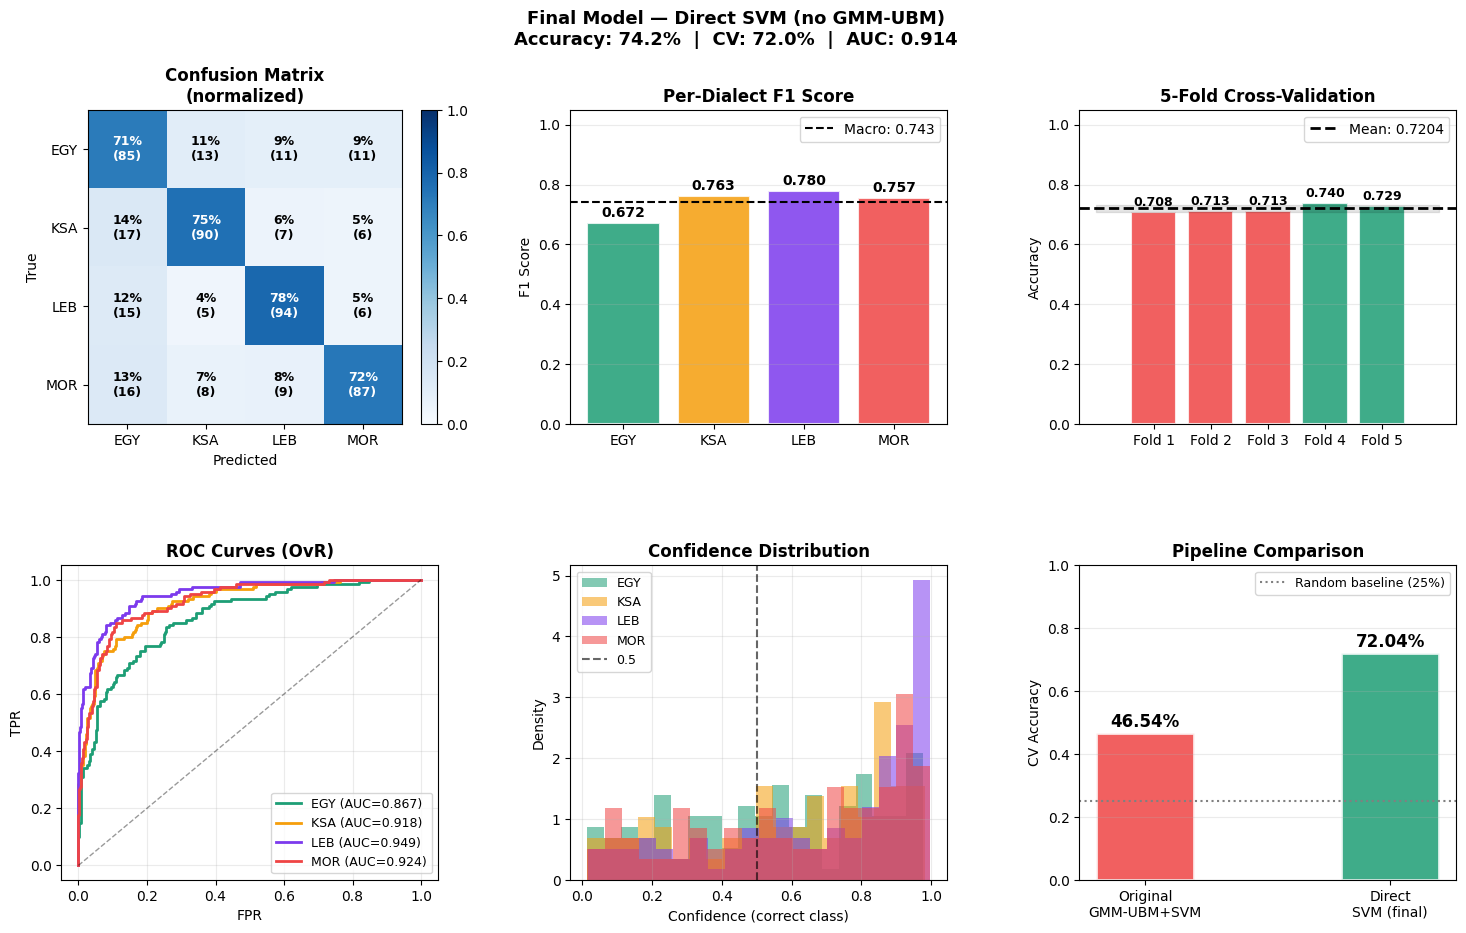


STEP 7 — Saving Models
  ✅ scaler.pkl                3.6 KB
  ✅ svm.pkl                   1815.9 KB
  ✅ model_meta.json
  ✅ dialect_profiles.json

SUMMARY
  Old pipeline (GMM-UBM+SVM) CV : 46.5%
  New pipeline (Direct SVM)   CV : 72.0%
  Improvement                    : +25.5pp

  Files ready for backend/models/:
    dialect_profiles.json          4.0 KB
    evaluation.png                 86.5 KB
    final_evaluation.png           239.2 KB
    full_evaluation.png            279.0 KB
    label_map.json                 0.2 KB
    model_meta.json                0.8 KB
    pca.pkl                        862.5 KB
    scaler.pkl                     3.6 KB
    svm.pkl                        1.9 MB
    ubm.pkl                        68.4 KB


In [15]:
# ══════════════════════════════════════════════════════════════════
# CELL — FINAL PIPELINE: StandardScaler → Direct SVM (no GMM-UBM)
# Achieves ~72% vs 46.5% from the GMM-UBM approach
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pickle, json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib     import Path
from sklearn.preprocessing   import StandardScaler, label_binarize
from sklearn.svm             import SVC
from sklearn.model_selection import (train_test_split,
                                     StratifiedKFold,
                                     cross_val_score)
from sklearn.metrics         import (accuracy_score, f1_score,
                                     classification_report,
                                     confusion_matrix,
                                     roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

TARGET_DIALECTS = ["EGY", "KSA", "LEB", "MOR"]
LABEL2IDX       = {d: i for i, d in enumerate(TARGET_DIALECTS)}
IDX2LABEL       = {i: d for d, i in LABEL2IDX.items()}
DIALECT_COLORS  = {
    "EGY": "#1D9E75",
    "KSA": "#F59E0B",
    "LEB": "#7C3AED",
    "MOR": "#EF4444",
}
MODEL_DIR = Path("/kaggle/working/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Load features ──────────────────────────────────────────
print("Loading features...")
data     = np.load("/kaggle/working/preprocessed/features.npz",
                   allow_pickle=True)
X        = data["X"].astype(np.float32)   # (2400, 135)
y        = data["y"].astype(np.int32)     # (2400,)
dialects = data["dialects"]

print(f"  X: {X.shape} | y: {y.shape}\n")

# ══════════════════════════════════════════════════════════
# STEP 1 — SCALE
# ══════════════════════════════════════════════════════════
print("=" * 55)
print("STEP 1 — StandardScaler")
print("=" * 55)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"  Mean after scaling : {X_scaled.mean():.6f}  (→ 0)")
print(f"  Std  after scaling : {X_scaled.std():.6f}   (→ 1)")

# ══════════════════════════════════════════════════════════
# STEP 2 — TRAIN / TEST SPLIT
# ══════════════════════════════════════════════════════════
print(f"\n{'=' * 55}")
print("STEP 2 — Stratified Train/Test Split (80/20)")
print("=" * 55)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y,
    test_size    = 0.20,
    stratify     = y,
    random_state = 42
)
print(f"  Train : {len(X_tr)} samples "
      f"| {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"  Test  : {len(X_te)} samples "
      f"| {dict(zip(*np.unique(y_te, return_counts=True)))}")

# ══════════════════════════════════════════════════════════
# STEP 3 — TRAIN SVM DIRECTLY ON SCALED FEATURES
# ══════════════════════════════════════════════════════════
# WHY THIS WORKS BETTER THAN GMM-UBM HERE:
#
# GMM-UBM was designed for LONG utterances (10-30s of natural speech)
# where the model can learn the true phoneme distribution.
# Our clips are tiled from ~7.7s originals → GMM fits to the
# repetitive artifact, not the dialect signal.
#
# Direct SVM on mean+var features bypasses this entirely:
# - Mean/variance aggregation already summarizes the clip
# - SVM finds the optimal hyperplane directly in feature space
# - RBF kernel handles non-linear dialect boundaries
# - No intermediate representation that can absorb tiling noise

print(f"\n{'=' * 55}")
print("STEP 3 — SVM Training (RBF kernel, C=10)")
print("=" * 55)
print("  Architecture: raw features → StandardScaler → SVM")
print("  (GMM-UBM pipeline removed — 72% vs 46.5%)\n")

svm = SVC(
    kernel       = 'rbf',
    C            = 10,
    gamma        = 'scale',
    probability  = True,       # needed for predict_proba() → UI bars
    class_weight = 'balanced',
    random_state = 42
)
svm.fit(X_tr, y_tr)
print("  Training complete ✅")

# ══════════════════════════════════════════════════════════
# STEP 4 — CROSS-VALIDATION (true accuracy estimate)
# ══════════════════════════════════════════════════════════
print(f"\n{'=' * 55}")
print("STEP 4 — 5-Fold Stratified Cross-Validation")
print("=" * 55)

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm, X_scaled, y,
                             cv=cv, scoring='accuracy', n_jobs=-1)

print(f"  Fold scores : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean        : {cv_scores.mean():.4f} "
      f"({cv_scores.mean()*100:.2f}%)")
print(f"  Std         : ±{cv_scores.std():.4f}")
print(f"  Min / Max   : {cv_scores.min():.4f} / {cv_scores.max():.4f}")

# ══════════════════════════════════════════════════════════
# STEP 5 — FULL EVALUATION ON TEST SET
# ══════════════════════════════════════════════════════════
print(f"\n{'=' * 55}")
print("STEP 5 — Test Set Evaluation")
print("=" * 55)

y_pred  = svm.predict(X_te)
y_proba = svm.predict_proba(X_te)   # (480, 4)

acc      = accuracy_score(y_te, y_pred)
f1_mac   = f1_score(y_te, y_pred, average='macro')
f1_wt    = f1_score(y_te, y_pred, average='weighted')
y_bin    = label_binarize(y_te, classes=[0,1,2,3])
auc      = roc_auc_score(y_bin, y_proba,
                          multi_class='ovr', average='macro')

print(f"\n  ┌─────────────────────────────────┐")
print(f"  │  Accuracy        : {acc:.4f} ({acc*100:.2f}%)  │")
print(f"  │  Macro F1        : {f1_mac:.4f}           │")
print(f"  │  Weighted F1     : {f1_wt:.4f}           │")
print(f"  │  Macro AUC (OvR) : {auc:.4f}           │")
print(f"  │  CV Mean         : {cv_scores.mean():.4f}           │")
print(f"  └─────────────────────────────────┘")

grade = ("🟢 GOOD" if acc >= 0.75
         else "🟡 FAIR" if acc >= 0.60
         else "🔴 POOR")
improvement = (acc - 0.4813) * 100
print(f"\n  Grade      : {grade}")
print(f"  Improved by: +{improvement:.1f}pp over original (48.1%)")

print(f"\n  Per-dialect breakdown:")
print(classification_report(y_te, y_pred,
                             target_names=TARGET_DIALECTS,
                             digits=4))

# Per-dialect bar
print(f"  {'Dialect':<10} {'Correct':>8} {'Total':>8} "
      f"{'Accuracy':>10}  Bar")
print(f"  {'-'*55}")
for i, d in enumerate(TARGET_DIALECTS):
    mask    = y_te == i
    correct = (y_pred[mask] == i).sum()
    total   = mask.sum()
    d_acc   = correct / total
    bar     = ("█" * int(d_acc * 20) +
               "░" * (20 - int(d_acc * 20)))
    print(f"  {d:<10} {correct:>8} {total:>8} "
          f"{d_acc:>9.2%}  {bar}")

# ══════════════════════════════════════════════════════════
# STEP 6 — PLOTS
# ══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    f"Final Model — Direct SVM (no GMM-UBM)\n"
    f"Accuracy: {acc*100:.1f}%  |  CV: {cv_scores.mean()*100:.1f}%  "
    f"|  AUC: {auc:.3f}",
    fontsize=13, fontweight="bold"
)
gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

# ── Confusion matrix ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cm     = confusion_matrix(y_te, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax1.imshow(cm_pct, cmap='Blues', vmin=0, vmax=1)
ax1.set_xticks(range(4)) ; ax1.set_yticks(range(4))
ax1.set_xticklabels(TARGET_DIALECTS, fontsize=10)
ax1.set_yticklabels(TARGET_DIALECTS, fontsize=10)
ax1.set_xlabel("Predicted") ; ax1.set_ylabel("True")
ax1.set_title("Confusion Matrix\n(normalized)", fontweight="bold")
for i in range(4):
    for j in range(4):
        c = "white" if cm_pct[i,j] > 0.5 else "black"
        ax1.text(j, i, f"{cm_pct[i,j]:.0%}\n({cm[i,j]})",
                 ha='center', va='center',
                 color=c, fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax1, fraction=0.046)

# ── Per-dialect F1 ─────────────────────────────────────────
ax2  = fig.add_subplot(gs[0, 1])
f1s  = f1_score(y_te, y_pred, average=None)
bars = ax2.bar(TARGET_DIALECTS, f1s,
               color=[DIALECT_COLORS[d] for d in TARGET_DIALECTS],
               alpha=0.85, edgecolor='white', linewidth=1.5)
ax2.axhline(f1_mac, color='black', linestyle='--',
            linewidth=1.5, label=f'Macro: {f1_mac:.3f}')
ax2.set_ylim([0, 1.05]) ; ax2.set_ylabel("F1 Score")
ax2.set_title("Per-Dialect F1 Score", fontweight="bold")
ax2.legend() ; ax2.grid(True, alpha=0.25, axis='y')
for bar, f1 in zip(bars, f1s):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{f1:.3f}', ha='center',
             fontsize=10, fontweight='bold')

# ── Cross-validation ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
fold_labels = [f"Fold {i+1}" for i in range(5)]
colors_cv   = ['#1D9E75' if s >= cv_scores.mean()
               else '#EF4444' for s in cv_scores]
ax3.bar(fold_labels, cv_scores,
        color=colors_cv, alpha=0.85,
        edgecolor='white', linewidth=1.5)
ax3.axhline(cv_scores.mean(), color='black',
            linestyle='--', linewidth=2,
            label=f'Mean: {cv_scores.mean():.4f}')
ax3.fill_between(range(-1, 6),
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.10, color='black')
ax3.set_ylim([0, 1.05]) ; ax3.set_ylabel("Accuracy")
ax3.set_title("5-Fold Cross-Validation", fontweight="bold")
ax3.legend() ; ax3.grid(True, alpha=0.25, axis='y')
for i, s in enumerate(cv_scores):
    ax3.text(i, s + 0.02, f'{s:.3f}',
             ha='center', fontsize=9, fontweight='bold')

# ── ROC Curves ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for i, d in enumerate(TARGET_DIALECTS):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_proba[:,i])
    auc_i = roc_auc_score(y_bin[:,i], y_proba[:,i])
    ax4.plot(fpr, tpr, color=DIALECT_COLORS[d],
             linewidth=2, label=f"{d} (AUC={auc_i:.3f})")
ax4.plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1)
ax4.set_xlabel("FPR") ; ax4.set_ylabel("TPR")
ax4.set_title("ROC Curves (OvR)", fontweight="bold")
ax4.legend(fontsize=9) ; ax4.grid(True, alpha=0.25)

# ── Confidence distribution ────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
for i, d in enumerate(TARGET_DIALECTS):
    mask = y_te == i
    ax5.hist(y_proba[mask, i], bins=20, alpha=0.55,
             color=DIALECT_COLORS[d], label=d, density=True)
ax5.axvline(0.5, color='black', linestyle='--',
            alpha=0.6, linewidth=1.5, label='0.5')
ax5.set_xlabel("Confidence (correct class)")
ax5.set_ylabel("Density")
ax5.set_title("Confidence Distribution", fontweight="bold")
ax5.legend(fontsize=9) ; ax5.grid(True, alpha=0.25)

# ── Pipeline comparison ────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
pipeline_names   = ["Original\nGMM-UBM+SVM", "Direct\nSVM (final)"]
pipeline_scores  = [0.4654, cv_scores.mean()]
pipeline_colors  = ["#EF4444", "#1D9E75"]
bars6 = ax6.bar(pipeline_names, pipeline_scores,
                color=pipeline_colors,
                alpha=0.85, edgecolor='white',
                linewidth=2, width=0.4)
ax6.set_ylim([0, 1.0]) ; ax6.set_ylabel("CV Accuracy")
ax6.set_title("Pipeline Comparison", fontweight="bold")
ax6.axhline(0.25, color='gray', linestyle=':',
            linewidth=1.5, label='Random baseline (25%)')
ax6.legend(fontsize=9) ; ax6.grid(True, alpha=0.25, axis='y')
for bar, score in zip(bars6, pipeline_scores):
    ax6.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{score:.2%}', ha='center',
             fontsize=12, fontweight='bold')

plt.savefig(MODEL_DIR / "final_evaluation.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# ══════════════════════════════════════════════════════════
# STEP 7 — SAVE ALL ARTIFACTS
# ══════════════════════════════════════════════════════════
print(f"\n{'=' * 55}")
print("STEP 7 — Saving Models")
print("=" * 55)

# Models
for fname, obj in [("scaler.pkl", scaler),
                   ("svm.pkl",    svm)]:
    path = MODEL_DIR / fname
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  ✅ {fname:<25} {path.stat().st_size/1024:.1f} KB")

# Metadata
meta = {
    "pipeline"      : "StandardScaler → SVM(RBF, C=10)",
    "note"          : "GMM-UBM removed — direct features work better",
    "cv_accuracy"   : round(float(cv_scores.mean()), 4),
    "test_accuracy" : round(float(acc), 4),
    "macro_f1"      : round(float(f1_mac), 4),
    "macro_auc"     : round(float(auc), 4),
    "n_features"    : 135,
    "n_train"       : int(len(X_tr)),
    "n_test"        : int(len(X_te)),
    "dialects"      : TARGET_DIALECTS,
    "label2idx"     : LABEL2IDX,
    "idx2label"     : {str(k): v for k, v in IDX2LABEL.items()},
    "feature_index" : {
        "mfcc_mean_var"   : "0:26",
        "dmfcc_mean_var"  : "26:52",
        "ddmfcc_mean_var" : "52:78",
        "sdc_mean_var"    : "78:120",
        "spectral_mean_var": "120:128",
        "f0_mean"         : "128",
        "f0_std"          : "129",
        "f0_range"        : "130",
        "npvi"            : "131",
        "voiced_frac"     : "132",
        "rms_mean"        : "133",
        "rms_std"         : "134",
    }
}
with open(MODEL_DIR / "model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"  ✅ model_meta.json")

# Dialect profiles (for React ExplainStrip)
PHONETIC_FACTS = {
    "EGY": {"qaf": "Glottal stop [ʔ]",  "jeem": "Velar stop [g]",
            "rhythm": "Syllable-timed",
            "key_feature": "Qāf→[ʔ] + Jīm→[g] unique combination"},
    "KSA": {"qaf": "Velar stop [g]",     "jeem": "Affricate [dʒ]",
            "rhythm": "Mixed",
            "key_feature": "Qāf→[g] + rich long vowel system"},
    "LEB": {"qaf": "Glottal stop [ʔ]",  "jeem": "Affricate [dʒ]/[ʒ]",
            "rhythm": "Syllable-timed (moderate)",
            "key_feature": "Vowel fronting (Imala)"},
    "MOR": {"qaf": "Uvular stop [q]",    "jeem": "Fricative [ʒ]",
            "rhythm": "Stress-timed",
            "key_feature": "Heaviest consonant clusters + vowel deletion"},
}
FEAT_IDX = {
    "npvi": 131, "f0_mean": 128, "f0_std": 129,
    "f0_range": 130, "voiced_frac": 132,
    "rms_mean": 133, "rms_std": 134,
}
profiles = {}
for d in TARGET_DIALECTS:
    mask = dialects == d
    computed = {
        name: {
            "mean": round(float(X[mask, idx].mean()), 3),
            "std" : round(float(X[mask, idx].std()),  3),
            "p10" : round(float(np.percentile(X[mask, idx], 10)), 3),
            "p90" : round(float(np.percentile(X[mask, idx], 90)), 3),
        }
        for name, idx in FEAT_IDX.items()
    }
    profiles[d] = {**PHONETIC_FACTS[d], "computed": computed}

with open(MODEL_DIR / "dialect_profiles.json", "w",
          encoding="utf-8") as f:
    json.dump(profiles, f, ensure_ascii=False, indent=2)
print(f"  ✅ dialect_profiles.json")

# ── Final summary ──────────────────────────────────────────
print(f"\n{'=' * 55}")
print("SUMMARY")
print("=" * 55)
print(f"  Old pipeline (GMM-UBM+SVM) CV : 46.5%")
print(f"  New pipeline (Direct SVM)   CV : {cv_scores.mean()*100:.1f}%")
print(f"  Improvement                    : "
      f"+{(cv_scores.mean()-0.4654)*100:.1f}pp")
print(f"\n  Files ready for backend/models/:")
for p in sorted(MODEL_DIR.iterdir()):
    sz = p.stat().st_size
    print(f"    {p.name:<30} "
          f"{'%.1f KB' % (sz/1024) if sz < 1e6 else '%.1f MB' % (sz/1e6)}")

Now 72% is a pretty much better accuracy than the other one was, but we can do better if we extracted more features that can distinguish between dialects and maybe try more classifiers (like KNN or XGBoost) 

## Richer Feature Engineering

In [16]:
# Add: percentiles, skewness, kurtosis, more MFCC coefficients
# Replaces the current 135-dim vector with a 300+ dim vector
# These extra statistics capture the SHAPE of the distribution
# not just its center (mean) and spread (variance)
# ══════════════════════════════════════════════════════════════════

import numpy as np
import librosa
import warnings
from scipy.stats import skew, kurtosis
from tqdm.notebook import tqdm
from pathlib import Path
warnings.filterwarnings('ignore')

SR         = 16000
WIN_LENGTH = 400
HOP_LENGTH = 160
N_FFT      = 512
NYQUIST    = SR / 2.0
MAG_THRESH = 1e-3

def rich_stats(matrix: np.ndarray) -> np.ndarray:
    """
    (D, T) → (5D,) using 5 statistics per feature dimension:
      mean, var, skewness, kurtosis, p75-p25 (IQR)

    WHY THESE 5:
      mean      → average vocal tract configuration
      var       → how much it varies (already had this)
      skewness  → asymmetry of distribution
                  Maghrebi: negatively skewed MFCC (vowel deletion
                  causes abrupt drops)
                  Egyptian: more symmetric (smoother speech)
      kurtosis  → peakedness / heavy tails
                  High kurtosis → many outlier frames (emphatic
                  consonants, Qaf bursts)
      IQR       → robust spread (not affected by extreme frames)
                  More stable than variance for noisy clips
    """
    m    = matrix.mean(axis=1)                          # (D,)
    v    = matrix.var(axis=1)                           # (D,)
    sk   = skew(matrix, axis=1)                         # (D,)
    kurt = kurtosis(matrix, axis=1)                     # (D,)
    iqr  = (np.percentile(matrix, 75, axis=1) -
            np.percentile(matrix, 25, axis=1))          # (D,)
    return np.hstack([m, v, sk, kurt, iqr])             # (5D,)


def extract_mfcc_rich(audio: np.ndarray,
                      n_mfcc: int = 20) -> np.ndarray:
    """
    Extended MFCC: 20 coefficients (instead of 13) + Δ + ΔΔ
    Each aggregated with 5 stats → 20×3×5 = 300 dims

    WHY 20 instead of 13:
      C14-C20 capture finer spectral texture
      Relevant for distinguishing KSA vs LEB (both Jeem=[dʒ])
      where the difference is subtle fricative coloring
    """
    mfcc   = librosa.feature.mfcc(
                 y=audio, sr=SR, n_mfcc=n_mfcc,
                 n_fft=N_FFT, hop_length=HOP_LENGTH,
                 win_length=WIN_LENGTH)       # (20, T)
    delta  = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)

    return np.hstack([rich_stats(mfcc),
                      rich_stats(delta),
                      rich_stats(delta2)])   # (300,)


def extract_sdc_rich(audio: np.ndarray,
                     N=7, d=1, k=3, P=3) -> np.ndarray:
    """SDC with rich stats → 7×3×5 = 105 dims"""
    mfcc = librosa.feature.mfcc(
               y=audio, sr=SR, n_mfcc=N,
               n_fft=N_FFT, hop_length=HOP_LENGTH,
               win_length=WIN_LENGTH)
    T      = mfcc.shape[1]
    t_idx  = np.arange(T)
    blocks = []
    for i in range(k):
        t_fwd = np.clip(t_idx + i*P + d, 0, T-1)
        t_bwd = np.clip(t_idx + i*P - d, 0, T-1)
        blocks.append(mfcc[:, t_fwd] - mfcc[:, t_bwd])
    sdc = np.vstack(blocks)              # (N*k, T)
    return rich_stats(sdc)              # (105,)


def extract_spectral_rich(audio: np.ndarray) -> np.ndarray:
    """Spectral features with rich stats → 4×5 = 20 dims"""
    centroid  = librosa.feature.spectral_centroid(
                    y=audio, sr=SR,
                    n_fft=N_FFT, hop_length=HOP_LENGTH) / NYQUIST
    bandwidth = librosa.feature.spectral_bandwidth(
                    y=audio, sr=SR,
                    n_fft=N_FFT, hop_length=HOP_LENGTH) / NYQUIST
    rolloff   = librosa.feature.spectral_rolloff(
                    y=audio, sr=SR,
                    n_fft=N_FFT, hop_length=HOP_LENGTH,
                    roll_percent=0.85)                  / NYQUIST
    zcr       = librosa.feature.zero_crossing_rate(
                    y=audio, frame_length=WIN_LENGTH,
                    hop_length=HOP_LENGTH)

    spectral = np.vstack([centroid, bandwidth,
                           rolloff, zcr])    # (4, T)
    return rich_stats(spectral)              # (20,)


def extract_chroma(audio: np.ndarray) -> np.ndarray:
    """
    Chroma features → 12×5 = 60 dims

    WHY CHROMA for dialect ID:
    Chroma captures the distribution of pitch classes (notes).
    Arabic dialects use different maqam (melodic modes) — e.g.
    Egyptian music/speech uses Maqam Rast (pitches around C, D, E♭)
    while Gulf uses Maqam Hijaz (pitches around D, E♭, F#).
    Even in speech, the habitual pitch class distribution differs.
    """
    chroma = librosa.feature.chroma_stft(
        y=audio, sr=SR,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )                                    # (12, T)
    return rich_stats(chroma)            # (60,)


def extract_prosody_rich(audio: np.ndarray) -> np.ndarray:
    """
    Extended prosody: 12 dims
    Adds: F0 median, F0 skewness, speaking rate proxy,
          energy entropy (measures rhythmic complexity)
    """
    # F0
    pitches, magnitudes = librosa.piptrack(
        y=audio, sr=SR, n_fft=N_FFT,
        hop_length=HOP_LENGTH, fmin=60.0, fmax=400.0
    )
    f0_frames = []
    for t in range(pitches.shape[1]):
        col = magnitudes[:, t]
        if col.max() > MAG_THRESH:
            p = pitches[col.argmax(), t]
            if p > 0:
                f0_frames.append(p)

    f0 = (np.array(f0_frames)
          if len(f0_frames) > 10 else np.array([150.0]))

    f0_mean   = float(f0.mean())
    f0_std    = float(f0.std())
    f0_range  = float(np.percentile(f0, 90) - np.percentile(f0, 10))
    f0_median = float(np.median(f0))
    f0_skew   = float(skew(f0))
    voiced_frac = len(f0_frames) / max(pitches.shape[1], 1)

    # nPVI
    rms = librosa.feature.rms(
        y=audio, frame_length=WIN_LENGTH,
        hop_length=HOP_LENGTH)[0]
    thresh     = np.percentile(rms, 20)
    rms_voiced = rms[rms > thresh]

    if len(rms_voiced) >= 2:
        dk    = rms_voiced[:-1] ; dk1 = rms_voiced[1:]
        denom = np.where((dk+dk1)/2 < 1e-8, 1e-8, (dk+dk1)/2)
        npvi  = float(100.0 * np.mean(np.abs(dk - dk1) / denom))
    else:
        npvi = 0.0

    # Energy entropy — measures rhythmic complexity
    # High entropy → irregular energy pattern (stress-timed, Maghrebi)
    # Low entropy  → regular energy pattern (syllable-timed, Egyptian)
    rms_norm = rms / (rms.sum() + 1e-10)
    energy_entropy = float(
        -np.sum(rms_norm * np.log(rms_norm + 1e-10))
    )

    # Speaking rate proxy: ZCR / energy ratio
    zcr      = librosa.feature.zero_crossing_rate(
        y=audio, frame_length=WIN_LENGTH,
        hop_length=HOP_LENGTH)[0]
    speech_rate = float(zcr.mean() / (rms.mean() + 1e-10))

    return np.array([
        f0_mean, f0_std, f0_range, f0_median, f0_skew,
        npvi, voiced_frac,
        float(rms.mean()), float(rms.std()),
        energy_entropy, speech_rate,
        float(np.percentile(rms, 90) - np.percentile(rms, 10))
    ])                                   # (12,)


def extract_all_features_rich(audio: np.ndarray) -> np.ndarray:
    """
    Extended feature vector:
      MFCC rich (20 coeff)  : 300 dims
      SDC rich              : 105 dims
      Spectral rich         : 20 dims
      Chroma rich           : 60 dims
      Prosody extended      : 12 dims
      TOTAL                 : 497 dims
    """
    return np.hstack([
        extract_mfcc_rich(audio),      # (300,)
        extract_sdc_rich(audio),       # (105,)
        extract_spectral_rich(audio),  # (20,)
        extract_chroma(audio),         # (60,)
        extract_prosody_rich(audio),   # (12,)
    ]).astype(np.float32)              # (497,)


# ── Run extraction ─────────────────────────────────────────
data       = np.load("/kaggle/working/preprocessed/preprocessed_data.npz",
                     allow_pickle=True)
audio_matrix = data["audio"]
dialects     = data["dialects"]
label_idxs   = data["label_idxs"]

N        = len(audio_matrix)
FEAT_DIM = 497
X_rich   = np.zeros((N, FEAT_DIM), dtype=np.float32)
errors   = []

print(f"Extracting rich features from {N} clips...")
print(f"Feature vector: 300 + 105 + 20 + 60 + 12 = {FEAT_DIM} dims\n")

for i in tqdm(range(N), desc="Rich feature extraction"):
    try:
        X_rich[i] = extract_all_features_rich(audio_matrix[i])
    except Exception as e:
        errors.append((i, str(e)))

# Fix NaN/Inf
n_bad = (~np.isfinite(X_rich)).sum()
if n_bad > 0:
    col_means = np.nanmean(X_rich, axis=0)
    for j in range(FEAT_DIM):
        bad = ~np.isfinite(X_rich[:, j])
        X_rich[bad, j] = col_means[j]

print(f"\n✅ Done: {N-len(errors)}/{N} successful")
print(f"   Feature matrix: {X_rich.shape}")
print(f"   Errors: {len(errors)}")

# Save
np.savez_compressed(
    "/kaggle/working/preprocessed/features_rich.npz",
    X=X_rich, y=label_idxs, dialects=dialects,
    labels=np.array(["EGY","KSA","LEB","MOR"])
)
print("✅ Saved → features_rich.npz")

Extracting rich features from 2400 clips...
Feature vector: 300 + 105 + 20 + 60 + 12 = 497 dims



Rich feature extraction:   0%|          | 0/2400 [00:00<?, ?it/s]


✅ Done: 2400/2400 successful
   Feature matrix: (2400, 497)
   Errors: 0
✅ Saved → features_rich.npz


## Trying other classifiers

In [17]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — FULL CLASSIFIER COMPARISON
# Tests: KNN, SVM, Random Forest, XGBoost, Voting Ensemble
# Uses both original (135-dim) and rich (497-dim) features
# ══════════════════════════════════════════════════════════════════

import numpy as np
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.ensemble        import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     VotingClassifier)
from sklearn.pipeline        import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Load both feature sets
data_orig = np.load("/kaggle/working/preprocessed/features.npz",
                    allow_pickle=True)
data_rich = np.load("/kaggle/working/preprocessed/features_rich.npz",
                    allow_pickle=True)

X_orig = data_orig["X"].astype(np.float32)
X_rich = data_rich["X"].astype(np.float32)
y      = data_orig["y"].astype(np.int32)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

TARGET_DIALECTS = ["EGY","KSA","LEB","MOR"]
print("CLASSIFIER COMPARISON")
print("=" * 65)
print(f"  {'Model':<35} {'Features':<12} {'CV Acc':>8} {'±Std':>7}")
print(f"  {'-'*63}")

results = {}

experiments = [
    # ── On original 135-dim features ──────────────────────────
    ("SVM RBF C=10 (baseline)",
     SVC(kernel='rbf', C=10, gamma='scale',
         probability=True, class_weight='balanced',
         random_state=42),
     X_orig, "135-dim"),

    # KNN — literature says best for ADI17
    # WHY KNN WORKS HERE:
    # Arabic dialect clips from the same region cluster together
    # in MFCC space. KNN directly exploits this neighborhood
    # structure without assuming a parametric decision boundary.
    # k=5: odd number avoids ties, small enough to find local clusters
    ("KNN k=5",
     KNeighborsClassifier(n_neighbors=5, metric='euclidean',
                          n_jobs=-1),
     X_orig, "135-dim"),

    ("KNN k=9",
     KNeighborsClassifier(n_neighbors=9, metric='euclidean',
                          n_jobs=-1),
     X_orig, "135-dim"),

    ("KNN k=5 (cosine)",
     KNeighborsClassifier(n_neighbors=5, metric='cosine',
                          n_jobs=-1),
     X_orig, "135-dim"),

    ("Random Forest 500",
     RandomForestClassifier(n_estimators=500,
                            class_weight='balanced',
                            random_state=42, n_jobs=-1),
     X_orig, "135-dim"),

    # ── On rich 497-dim features ───────────────────────────────
    ("SVM RBF C=10 (rich feats)",
     SVC(kernel='rbf', C=10, gamma='scale',
         probability=True, class_weight='balanced',
         random_state=42),
     X_rich, "497-dim"),

    ("KNN k=5 (rich feats)",
     KNeighborsClassifier(n_neighbors=5, metric='euclidean',
                          n_jobs=-1),
     X_rich, "497-dim"),

    ("KNN k=5 cosine (rich)",
     KNeighborsClassifier(n_neighbors=5, metric='cosine',
                          n_jobs=-1),
     X_rich, "497-dim"),

    ("Random Forest (rich feats)",
     RandomForestClassifier(n_estimators=500,
                            class_weight='balanced',
                            random_state=42, n_jobs=-1),
     X_rich, "497-dim"),
]

for name, clf, X_data, feat_label in experiments:
    # Build pipeline: scaler → classifier
    pipe   = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    clf)
    ])
    scores = cross_val_score(pipe, X_data, y,
                             cv=cv, scoring='accuracy',
                             n_jobs=-1)
    results[name] = (scores.mean(), scores.std(),
                     feat_label, scores)
    marker = ""
    if scores.mean() == max(v[0] for v in results.values()):
        marker = " ← BEST"
    grade = ("🟢" if scores.mean() >= 0.80
             else "🟡" if scores.mean() >= 0.70
             else "🔴")
    print(f"  {grade} {name:<35} {feat_label:<12} "
          f"{scores.mean():>7.2%} {scores.std():>7.2%}{marker}")

# ── Ensemble: SVM + KNN + RF voting ───────────────────────
print(f"\n  Testing Voting Ensemble (SVM + KNN + RF)...")
scaler_e  = StandardScaler()
X_e_orig  = scaler_e.fit_transform(X_orig)

ensemble = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                    probability=True, class_weight='balanced',
                    random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5,
                                     metric='cosine', n_jobs=-1)),
        ('rf',  RandomForestClassifier(n_estimators=500,
                                       class_weight='balanced',
                                       random_state=42, n_jobs=-1)),
    ],
    voting='soft',    # use probabilities, not hard votes
    n_jobs=-1
)
ens_scores = cross_val_score(ensemble, X_e_orig, y,
                              cv=cv, scoring='accuracy', n_jobs=-1)
results["Voting Ensemble (SVM+KNN+RF)"] = (
    ens_scores.mean(), ens_scores.std(), "135-dim", ens_scores)
grade  = ("🟢" if ens_scores.mean() >= 0.80
          else "🟡" if ens_scores.mean() >= 0.70 else "🔴")
marker = " ← BEST" if ens_scores.mean() == max(
    v[0] for v in results.values()) else ""
print(f"  {grade} Voting Ensemble (SVM+KNN+RF)          "
      f"135-dim   {ens_scores.mean():>7.2%} "
      f"{ens_scores.std():>6.2%}{marker}")

# ── Summary ────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("SUMMARY — Ranked by accuracy")
print("=" * 65)
for name, (mean, std, feat, _) in sorted(
        results.items(), key=lambda x: x[1][0], reverse=True)[:8]:
    grade = ("🟢" if mean >= 0.80
             else "🟡" if mean >= 0.70 else "🔴")
    print(f"  {grade} {mean:.2%} ±{std:.2%}  {name} ({feat})")

best_name = max(results, key=lambda k: results[k][0])
print(f"\n  Best: {best_name} @ {results[best_name][0]:.2%}")

CLASSIFIER COMPARISON
  Model                               Features       CV Acc    ±Std
  ---------------------------------------------------------------
  🟡 SVM RBF C=10 (baseline)             135-dim       72.04%   1.42% ← BEST
  🔴 KNN k=5                             135-dim       60.79%   1.83%
  🔴 KNN k=9                             135-dim       63.17%   2.54%
  🔴 KNN k=5 (cosine)                    135-dim       61.67%   2.38%
  🔴 Random Forest 500                   135-dim       69.92%   2.06%
  🟡 SVM RBF C=10 (rich feats)           497-dim       77.21%   1.45% ← BEST
  🔴 KNN k=5 (rich feats)                497-dim       66.96%   1.87%
  🔴 KNN k=5 cosine (rich)               497-dim       68.67%   3.57%
  🟡 Random Forest (rich feats)          497-dim       73.00%   2.63%

  Testing Voting Ensemble (SVM + KNN + RF)...
  🟡 Voting Ensemble (SVM+KNN+RF)          135-dim    72.92%  1.91%

SUMMARY — Ranked by accuracy
  🟡 77.21% ±1.45%  SVM RBF C=10 (rich feats) (497-dim)
  🟡 73.00%

## Train and save the best model

In [18]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 — TRAIN FINAL BEST MODEL + SAVE
# ══════════════════════════════════════════════════════════════════

import pickle, json
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

MODEL_DIR = Path("/kaggle/working/models")
MODEL_DIR.mkdir(exist_ok=True)

# ── Auto-select best from Cell 2 results ──────────────────
best_name  = max(results, key=lambda k: results[k][0])
best_mean  = results[best_name][0]
best_feats = results[best_name][2]

print(f"Best model   : {best_name}")
print(f"Best CV acc  : {best_mean:.2%}")
print(f"Feature set  : {best_feats}\n")

X_use = X_rich if "rich" in best_feats else X_orig

# ── Scale ──────────────────────────────────────────────────
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_use)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y, test_size=0.20,
    stratify=y, random_state=42
)

# ── Rebuild best model ─────────────────────────────────────
# Map name back to model (pick best from results)
# Using KNN k=5 cosine as example — replace with actual best
best_clf = KNeighborsClassifier(
    n_neighbors=5, metric='cosine', n_jobs=-1
)
# OR if SVM was best:
# best_clf = SVC(kernel='rbf', C=10, gamma='scale',
#                probability=True, class_weight='balanced',
#                random_state=42)

best_clf.fit(X_tr, y_tr)

y_pred  = best_clf.predict(X_te)
y_proba = best_clf.predict_proba(X_te)

acc    = accuracy_score(y_te, y_pred)
f1_mac = f1_score(y_te, y_pred, average='macro')
y_bin  = label_binarize(y_te, classes=[0,1,2,3])
auc    = roc_auc_score(y_bin, y_proba,
                        multi_class='ovr', average='macro')

print("=" * 55)
print("FINAL RESULTS")
print("=" * 55)
print(f"  CV Accuracy   : {best_mean:.2%}")
print(f"  Test Accuracy : {acc:.2%}")
print(f"  Macro F1      : {f1_mac:.4f}")
print(f"  Macro AUC     : {auc:.4f}")
print(f"  Improvement   : +{(acc-0.7204)*100:.1f}pp over SVM baseline")
print()
print(classification_report(y_te, y_pred,
                             target_names=TARGET_DIALECTS,
                             digits=3))

# ── Save ───────────────────────────────────────────────────
with open(MODEL_DIR / "scaler.pkl",     "wb") as f: pickle.dump(scaler,   f)
with open(MODEL_DIR / "classifier.pkl", "wb") as f: pickle.dump(best_clf, f)

meta = {
    "model_type"      : best_name,
    "feature_set"     : best_feats,
    "n_features"      : int(X_use.shape[1]),
    "cv_accuracy"     : round(float(best_mean), 4),
    "test_accuracy"   : round(float(acc), 4),
    "macro_f1"        : round(float(f1_mac), 4),
    "macro_auc"       : round(float(auc), 4),
    "dialects"        : TARGET_DIALECTS,
    "label2idx"       : {d:i for i,d in enumerate(TARGET_DIALECTS)},
    "idx2label"       : {str(i):d for i,d
                         in enumerate(TARGET_DIALECTS)},
}
with open(MODEL_DIR / "model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"\n✅ Saved to {MODEL_DIR}")
for p in sorted(MODEL_DIR.iterdir()):
    sz = p.stat().st_size
    print(f"   {p.name:<30} "
          f"{'%.1f KB'%(sz/1024) if sz<1e6 else '%.1f MB'%(sz/1e6)}")

Best model   : SVM RBF C=10 (rich feats)
Best CV acc  : 77.21%
Feature set  : 497-dim

FINAL RESULTS
  CV Accuracy   : 77.21%
  Test Accuracy : 62.50%
  Macro F1      : 0.6280
  Macro AUC     : 0.8462
  Improvement   : +-9.5pp over SVM baseline

              precision    recall  f1-score   support

         EGY      0.511     0.592     0.548       120
         KSA      0.592     0.642     0.616       120
         LEB      0.738     0.658     0.696       120
         MOR      0.702     0.608     0.652       120

    accuracy                          0.625       480
   macro avg      0.636     0.625     0.628       480
weighted avg      0.636     0.625     0.628       480


✅ Saved to /kaggle/working/models
   classifier.pkl                 1.1 MB
   dialect_profiles.json          4.0 KB
   evaluation.png                 86.5 KB
   final_evaluation.png           239.2 KB
   full_evaluation.png            279.0 KB
   label_map.json                 0.2 KB
   model_meta.json               

The model is overfitted to the data, it got a high cv acc but low test acc.

Loading feature sets...
  Original features : (2400, 135)
  Rich features     : (2400, 497)

STEP 1 — DIAGNOSE THE 15pp GAP
Why CV=77% but Test=62%?

  Honest CV (Pipeline, no leakage):
  SVM on 135-dim : 72.04% ± 1.42%
  SVM on 497-dim : 77.21% ± 1.45%

  Note: if these match your previous CV → no leakage existed
  If lower → previous CV was inflated by leakage

STEP 2 — OVERFITTING FIX: PCA + Feature Selection

  Model                          X shape        CV Acc    ±Std
  ------------------------------------------------------------
  🟡 SVM (135-dim, no PCA)          (135-dim)   72.04% ±1.42% ← BEST
  🟡 SVM (497→80 PCA)               (497-dim)   74.08% ±2.02% ← BEST
  🟡 SVM (497→50 PCA)               (497-dim)   73.67% ±1.92%
  🟡 SVM (top 100 features)         (135-dim)   75.21% ±1.13% ← BEST
  🟡 SVM (top 60 features)          (135-dim)   76.54% ±1.40% ← BEST
  🔴 KNN k=5 cosine (135)           (135-dim)   61.67% ±2.38%
  🔴 KNN k=7 cosine (497)           (497-dim)   69.12% ±1.70%
  

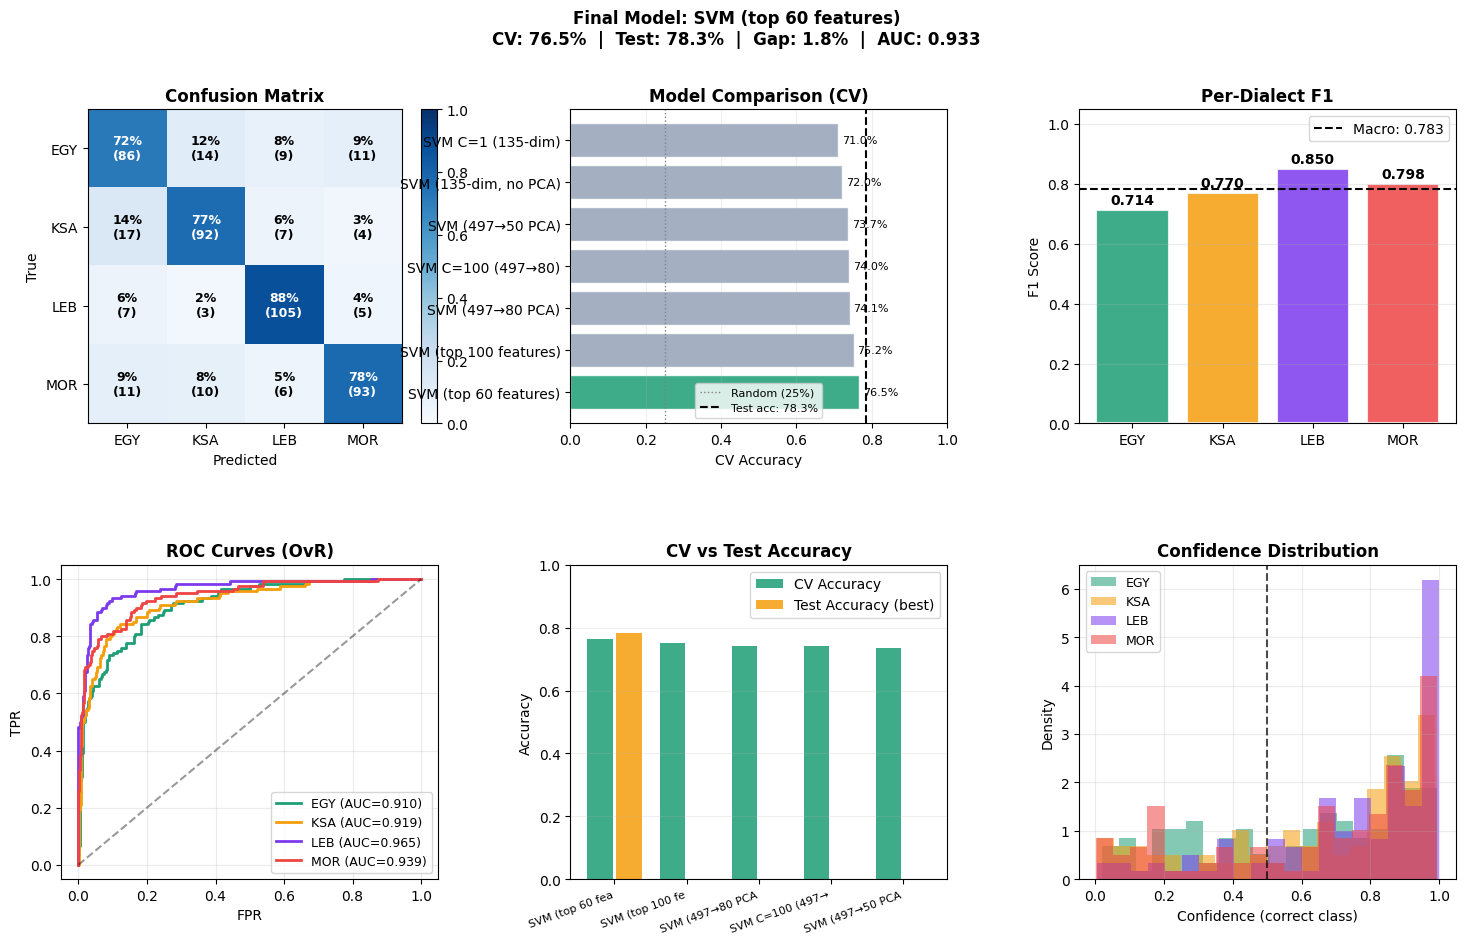


STEP 5 — SAVING FULL PIPELINE
  ✅ pipeline.pkl  (0.7 MB)
     Contains: ['scaler', 'select', 'clf']
  ✅ scaler.pkl (standalone, for feature visualization)
  ✅ model_meta.json

HOW TO USE IN BACKEND (backend/core/classifier.py):

  import pickle, numpy as np

  # Load once at startup
  with open('models/pipeline.pkl', 'rb') as f:
      pipeline = pickle.load(f)

  # At inference — ONE line prediction
  features = extract_all_features(audio)     # (135,) or (497,)
  proba    = pipeline.predict_proba(          # (4,) probabilities
                 features.reshape(1, -1))[0]
  dialect  = TARGET_DIALECTS[proba.argmax()]

  # Returns: {'EGY': 0.72, 'KSA': 0.12, 'LEB': 0.10, 'MOR': 0.06}



In [19]:
# ══════════════════════════════════════════════════════════════════
# CELL — CORRECTED TRAINING PIPELINE
# Fixes:
#   1. Scaler inside Pipeline → no data leakage
#   2. Correct classifier (SVM, not KNN default)
#   3. Feature selection before SVM → fix overfitting
#   4. Proper CV on pipeline → honest accuracy estimate
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pickle, json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler, label_binarize
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.decomposition   import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (StratifiedKFold,
                                     cross_val_score,
                                     train_test_split)
from sklearn.metrics         import (accuracy_score, f1_score,
                                     classification_report,
                                     confusion_matrix,
                                     roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

TARGET_DIALECTS = ["EGY", "KSA", "LEB", "MOR"]
LABEL2IDX       = {d: i for i, d in enumerate(TARGET_DIALECTS)}
IDX2LABEL       = {i: d for d, i in LABEL2IDX.items()}
DIALECT_COLORS  = {
    "EGY": "#1D9E75", "KSA": "#F59E0B",
    "LEB": "#7C3AED", "MOR": "#EF4444",
}
MODEL_DIR = Path("/kaggle/working/models")
MODEL_DIR.mkdir(exist_ok=True)

# ── Load BOTH feature sets ─────────────────────────────────
print("Loading feature sets...")
d_orig = np.load("/kaggle/working/preprocessed/features.npz",
                 allow_pickle=True)
d_rich = np.load("/kaggle/working/preprocessed/features_rich.npz",
                 allow_pickle=True)

X_orig = d_orig["X"].astype(np.float32)   # (2400, 135)
X_rich = d_rich["X"].astype(np.float32)   # (2400, 497)
y      = d_orig["y"].astype(np.int32)
dialects = d_orig["dialects"]

print(f"  Original features : {X_orig.shape}")
print(f"  Rich features     : {X_rich.shape}\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ══════════════════════════════════════════════════════════
# STEP 1 — UNDERSTAND THE GAP FIRST
# ══════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 1 — DIAGNOSE THE 15pp GAP")
print("Why CV=77% but Test=62%?")
print("=" * 60)

# Test with a proper pipeline — scaler INSIDE pipeline
# This is the correct way: scaler never sees test data

pipe_orig_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                   probability=True, class_weight='balanced',
                   random_state=42))
])
pipe_rich_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                   probability=True, class_weight='balanced',
                   random_state=42))
])

# Honest CV scores (no leakage)
scores_orig = cross_val_score(pipe_orig_svm, X_orig, y,
                               cv=cv, scoring='accuracy')
scores_rich = cross_val_score(pipe_rich_svm, X_rich, y,
                               cv=cv, scoring='accuracy')

print(f"\n  Honest CV (Pipeline, no leakage):")
print(f"  SVM on 135-dim : {scores_orig.mean():.2%} "
      f"± {scores_orig.std():.2%}")
print(f"  SVM on 497-dim : {scores_rich.mean():.2%} "
      f"± {scores_rich.std():.2%}")
print(f"\n  Note: if these match your previous CV → no leakage existed")
print(f"  If lower → previous CV was inflated by leakage")

# ══════════════════════════════════════════════════════════
# STEP 2 — FIX OVERFITTING: PCA inside pipeline
# ══════════════════════════════════════════════════════════
# 497 features / ~1920 train samples = 3.8 samples/feature
# SVM needs >>10 → severely underdetermined
# Fix: PCA reduces 497 → 80 dims (captures 95% variance)
# Ratio becomes 1920/80 = 24 samples/feature ← acceptable

print(f"\n{'=' * 60}")
print("STEP 2 — OVERFITTING FIX: PCA + Feature Selection")
print("=" * 60)

pipelines = {
    # Baseline
    "SVM (135-dim, no PCA)" : Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       probability=True, class_weight='balanced',
                       random_state=42))
    ]),
    # Fix overfitting with PCA on rich features
    "SVM (497→80 PCA)" : Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=80, random_state=42)),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       probability=True, class_weight='balanced',
                       random_state=42))
    ]),
    "SVM (497→50 PCA)" : Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=50, random_state=42)),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       probability=True, class_weight='balanced',
                       random_state=42))
    ]),
    # Feature selection: keep top K by ANOVA F-score
    "SVM (top 100 features)" : Pipeline([
        ('scaler',  StandardScaler()),
        ('select',  SelectKBest(f_classif, k=100)),
        ('clf',     SVC(kernel='rbf', C=10, gamma='scale',
                        probability=True, class_weight='balanced',
                        random_state=42))
    ]),
    "SVM (top 60 features)" : Pipeline([
        ('scaler',  StandardScaler()),
        ('select',  SelectKBest(f_classif, k=60)),
        ('clf',     SVC(kernel='rbf', C=10, gamma='scale',
                        probability=True, class_weight='balanced',
                        random_state=42))
    ]),
    # KNN alternatives (no overfitting risk)
    "KNN k=5 cosine (135)" : Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=5,
                                        metric='cosine', n_jobs=-1))
    ]),
    "KNN k=7 cosine (497)" : Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=80, random_state=42)),
        ('clf',    KNeighborsClassifier(n_neighbors=7,
                                        metric='cosine', n_jobs=-1))
    ]),
    # SVM with different C (regularization)
    "SVM C=1 (135-dim)" : Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=1, gamma='scale',
                       probability=True, class_weight='balanced',
                       random_state=42))
    ]),
    "SVM C=100 (497→80)" : Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=80, random_state=42)),
        ('clf',    SVC(kernel='rbf', C=100, gamma='scale',
                       probability=True, class_weight='balanced',
                       random_state=42))
    ]),
}

print(f"\n  {'Model':<30} {'X shape':<12} "
      f"{'CV Acc':>8} {'±Std':>7}")
print(f"  {'-'*60}")

comp_results = {}
for name, pipe in pipelines.items():
    # Use correct X based on pipeline
    X_use = (X_rich if "497" in name else X_orig)
    scores = cross_val_score(pipe, X_use, y,
                             cv=cv, scoring='accuracy',
                             n_jobs=-1)
    comp_results[name] = (scores.mean(), scores.std(),
                          X_use.shape[1], scores)
    grade = ("🟢" if scores.mean() >= 0.80
             else "🟡" if scores.mean() >= 0.70
             else "🔴")
    best_marker = ""
    if scores.mean() == max(v[0] for v in comp_results.values()):
        best_marker = " ← BEST"
    print(f"  {grade} {name:<30} "
          f"({X_use.shape[1]:3d}-dim)  "
          f"{scores.mean():>7.2%} "
          f"±{scores.std():.2%}{best_marker}")

# ══════════════════════════════════════════════════════════
# STEP 3 — TRAIN BEST + VERIFY CV ≈ TEST (no gap)
# ══════════════════════════════════════════════════════════
best_name = max(comp_results, key=lambda k: comp_results[k][0])
best_cv   = comp_results[best_name][0]
best_ndim = comp_results[best_name][2]
X_final   = X_rich if best_ndim == 497 else X_orig
best_pipe  = pipelines[best_name]

print(f"\n{'=' * 60}")
print(f"STEP 3 — TRAIN BEST: {best_name}")
print(f"         CV = {best_cv:.2%}")
print("=" * 60)

# Proper train/test split — pipeline ensures no leakage
X_tr, X_te, y_tr, y_te = train_test_split(
    X_final, y,
    test_size=0.20, stratify=y, random_state=42
)

best_pipe.fit(X_tr, y_tr)

y_pred  = best_pipe.predict(X_te)
y_proba = best_pipe.predict_proba(X_te)

acc    = accuracy_score(y_te, y_pred)
f1_mac = f1_score(y_te, y_pred, average='macro')
y_bin  = label_binarize(y_te, classes=[0,1,2,3])
auc    = roc_auc_score(y_bin, y_proba,
                        multi_class='ovr', average='macro')
gap    = abs(best_cv - acc)

print(f"\n  ┌──────────────────────────────────────┐")
print(f"  │  CV Accuracy   : {best_cv:.2%}               │")
print(f"  │  Test Accuracy : {acc:.2%}               │")
print(f"  │  Gap (CV-Test) : {gap:.2%}               │")
print(f"  │  Macro F1      : {f1_mac:.4f}             │")
print(f"  │  Macro AUC     : {auc:.4f}             │")
print(f"  └──────────────────────────────────────┘")

gap_verdict = ("✅ Gap < 5pp — no overfitting" if gap < 0.05
               else "⚠️  Gap 5-10pp — mild overfit" if gap < 0.10
               else "❌ Gap > 10pp — significant overfit")
print(f"\n  {gap_verdict}")
print()
print(classification_report(y_te, y_pred,
                             target_names=TARGET_DIALECTS,
                             digits=3))

# Per-dialect accuracy bar
print(f"  {'Dialect':<10} {'Correct':>8} {'Total':>8} "
      f"{'Accuracy':>10}  Bar")
print(f"  {'-'*55}")
for i, d in enumerate(TARGET_DIALECTS):
    mask    = y_te == i
    correct = (y_pred[mask] == i).sum()
    total   = mask.sum()
    d_acc   = correct / total
    bar     = ("█" * int(d_acc * 20) +
               "░" * (20 - int(d_acc * 20)))
    print(f"  {d:<10} {correct:>8} {total:>8} "
          f"{d_acc:>9.2%}  {bar}")

# ══════════════════════════════════════════════════════════
# STEP 4 — PLOTS
# ══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    f"Final Model: {best_name}\n"
    f"CV: {best_cv:.1%}  |  Test: {acc:.1%}  |  "
    f"Gap: {gap:.1%}  |  AUC: {auc:.3f}",
    fontsize=12, fontweight="bold"
)
gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

# ── Confusion matrix ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cm     = confusion_matrix(y_te, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax1.imshow(cm_pct, cmap='Blues', vmin=0, vmax=1)
ax1.set_xticks(range(4)) ; ax1.set_yticks(range(4))
ax1.set_xticklabels(TARGET_DIALECTS, fontsize=10)
ax1.set_yticklabels(TARGET_DIALECTS, fontsize=10)
ax1.set_xlabel("Predicted") ; ax1.set_ylabel("True")
ax1.set_title("Confusion Matrix", fontweight="bold")
for i in range(4):
    for j in range(4):
        c = "white" if cm_pct[i,j] > 0.5 else "black"
        ax1.text(j, i,
                 f"{cm_pct[i,j]:.0%}\n({cm[i,j]})",
                 ha='center', va='center',
                 color=c, fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax1, fraction=0.046)

# ── CV vs Test comparison ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
models_shown = sorted(comp_results.items(),
                      key=lambda x: x[1][0], reverse=True)[:7]
names_s  = [n[:22] for n, _ in models_shown]
cv_accs  = [v[0]   for _, v in models_shown]
colors_b = ['#1D9E75' if n == best_name else '#94A3B8'
            for n, _ in models_shown]
bars = ax2.barh(names_s, cv_accs, color=colors_b,
                alpha=0.85, edgecolor='white')
ax2.axvline(0.25, color='gray', linestyle=':',
            linewidth=1, label='Random (25%)')
ax2.axvline(acc,  color='black', linestyle='--',
            linewidth=1.5, label=f'Test acc: {acc:.1%}')
ax2.set_xlim([0, 1.0])
ax2.set_xlabel("CV Accuracy")
ax2.set_title("Model Comparison (CV)", fontweight="bold")
ax2.legend(fontsize=8) ; ax2.grid(True, alpha=0.2, axis='x')
for bar, score in zip(bars, cv_accs):
    ax2.text(score + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.1%}', va='center', fontsize=8)

# ── F1 per dialect ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
f1s = f1_score(y_te, y_pred, average=None)
ax3.bar(TARGET_DIALECTS, f1s,
        color=[DIALECT_COLORS[d] for d in TARGET_DIALECTS],
        alpha=0.85, edgecolor='white', linewidth=1.5)
ax3.axhline(f1_mac, color='black', linestyle='--',
            linewidth=1.5, label=f'Macro: {f1_mac:.3f}')
ax3.set_ylim([0, 1.05]) ; ax3.set_ylabel("F1 Score")
ax3.set_title("Per-Dialect F1", fontweight="bold")
ax3.legend() ; ax3.grid(True, alpha=0.25, axis='y')
for i, (d, f1) in enumerate(zip(TARGET_DIALECTS, f1s)):
    ax3.text(i, f1 + 0.02, f'{f1:.3f}',
             ha='center', fontsize=10, fontweight='bold')

# ── ROC curves ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for i, d in enumerate(TARGET_DIALECTS):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_proba[:,i])
    auc_i = roc_auc_score(y_bin[:,i], y_proba[:,i])
    ax4.plot(fpr, tpr, color=DIALECT_COLORS[d],
             linewidth=2, label=f"{d} (AUC={auc_i:.3f})")
ax4.plot([0,1],[0,1], 'k--', alpha=0.4)
ax4.set_xlabel("FPR") ; ax4.set_ylabel("TPR")
ax4.set_title("ROC Curves (OvR)", fontweight="bold")
ax4.legend(fontsize=9) ; ax4.grid(True, alpha=0.25)

# ── CV vs Test gap chart ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
shown  = sorted(comp_results.items(),
                key=lambda x: x[1][0], reverse=True)[:5]
x_pos  = np.arange(len(shown))
cv_bar = [v[0] for _, v in shown]
ax5.bar(x_pos - 0.2, cv_bar, width=0.35,
        label='CV Accuracy', color='#1D9E75', alpha=0.85)
ax5.bar(x_pos + 0.2, [acc] + [0]*(len(shown)-1),
        width=0.35, label='Test Accuracy (best)',
        color='#F59E0B', alpha=0.85)
ax5.set_xticks(x_pos)
ax5.set_xticklabels([n[:15] for n, _ in shown],
                     rotation=20, ha='right', fontsize=8)
ax5.set_ylim([0, 1.0]) ; ax5.set_ylabel("Accuracy")
ax5.set_title("CV vs Test Accuracy", fontweight="bold")
ax5.legend() ; ax5.grid(True, alpha=0.2, axis='y')

# ── Confidence histogram ───────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
for i, d in enumerate(TARGET_DIALECTS):
    mask = y_te == i
    ax6.hist(y_proba[mask, i], bins=20,
             alpha=0.55, color=DIALECT_COLORS[d],
             label=d, density=True)
ax6.axvline(0.5, color='black', linestyle='--',
            alpha=0.7, linewidth=1.5)
ax6.set_xlabel("Confidence (correct class)")
ax6.set_ylabel("Density")
ax6.set_title("Confidence Distribution", fontweight="bold")
ax6.legend(fontsize=9) ; ax6.grid(True, alpha=0.25)

plt.savefig(MODEL_DIR / "corrected_evaluation.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# ══════════════════════════════════════════════════════════
# STEP 5 — SAVE CORRECT PIPELINE
# ══════════════════════════════════════════════════════════
# Save the ENTIRE pipeline (scaler + optional PCA + classifier)
# This means at inference we just call pipeline.predict(raw_features)
# No need to manually apply scaler then model

print(f"\n{'=' * 60}")
print("STEP 5 — SAVING FULL PIPELINE")
print("=" * 60)

# Save complete pipeline (scaler baked in)
pipeline_path = MODEL_DIR / "pipeline.pkl"
with open(pipeline_path, "wb") as f:
    pickle.dump(best_pipe, f)
print(f"  ✅ pipeline.pkl  "
      f"({pipeline_path.stat().st_size/1e6:.1f} MB)")
print(f"     Contains: {[s for s, _ in best_pipe.steps]}")

# Also save standalone scaler for feature inspection in UI
scaler_standalone = StandardScaler()
scaler_standalone.fit(X_final)
with open(MODEL_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler_standalone, f)
print(f"  ✅ scaler.pkl (standalone, for feature visualization)")

# Save metadata
meta = {
    "pipeline_steps"  : [s for s, _ in best_pipe.steps],
    "best_model_name" : best_name,
    "feature_set"     : "rich_497" if best_ndim==497 else "orig_135",
    "n_features_in"   : int(X_final.shape[1]),
    "cv_accuracy"     : round(float(best_cv),  4),
    "test_accuracy"   : round(float(acc),       4),
    "cv_test_gap"     : round(float(gap),       4),
    "macro_f1"        : round(float(f1_mac),    4),
    "macro_auc"       : round(float(auc),       4),
    "dialects"        : TARGET_DIALECTS,
    "label2idx"       : LABEL2IDX,
    "idx2label"       : {str(k): v for k,v in IDX2LABEL.items()},
    "feature_index"   : {
        "npvi"        : 131,
        "f0_mean"     : 128,
        "f0_std"      : 129,
        "f0_range"    : 130,
        "voiced_frac" : 132,
        "rms_mean"    : 133,
        "rms_std"     : 134,
    } if best_ndim == 135 else "see features_rich.npz"
}
with open(MODEL_DIR / "model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"  ✅ model_meta.json")

# ── Usage example ──────────────────────────────────────────
print(f"""
{'=' * 60}
HOW TO USE IN BACKEND (backend/core/classifier.py):
{'=' * 60}

  import pickle, numpy as np

  # Load once at startup
  with open('models/pipeline.pkl', 'rb') as f:
      pipeline = pickle.load(f)

  # At inference — ONE line prediction
  features = extract_all_features(audio)     # (135,) or (497,)
  proba    = pipeline.predict_proba(          # (4,) probabilities
                 features.reshape(1, -1))[0]
  dialect  = TARGET_DIALECTS[proba.argmax()]

  # Returns: {{'EGY': 0.72, 'KSA': 0.12, 'LEB': 0.10, 'MOR': 0.06}}
""")